In [1]:
import snapatac2 as snap
import os
import sys
import scanpy as sc
import pandas as pd 
#sys.path.append('..')
#import Py_mTCall_tools.variant_calling
import importlib
#from Py_mTCall_tools import process_and_integrate_variants  # Use the package name from setup.py
import kaleido
import plotly.io as pio
sys.path.insert(0, '/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Py-mTCall')
import Py_mTCall_tools.variant_calling_ultra_fast as vc


KeyboardInterrupt: 

In [4]:
import snapatac2 as snap
import os
import sys
import scanpy as sc
import pandas as pd 
import anndata as ad
import scvi

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data = ad.read_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_surg_blood/data.h5ad")

In [ ]:
data = snap.pp.import_fragments(
    "/Users/lucascortes/Documents/Pickett/Mike_Keogh/Data/241121-PBMC_results_masked/fragments.tsv.gz",
    chrom_sizes=snap.genome.hg38,  #
    sorted_by_barcode=False,
)
data          

AnnData object with n_obs × n_vars = 24325 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

2025-11-11 15:52:34 - INFO - Computing fragment size distribution...


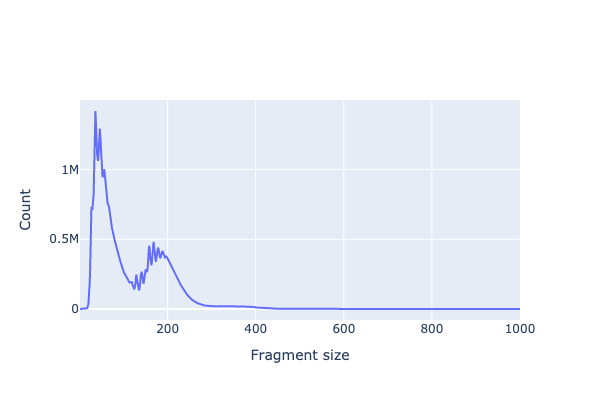

In [ ]:
## Bit of extra information:
'''
1. Nucleosome-Free Region (NFR): The majority of fragments are short, typically around 80-300 base pairs (bp) in length. 
These short fragments represent regions of open chromatin where DNA is relatively accessible and not bound to nucleosomes. 
These regions are often referred to as nucleosome-free regions (NFRs) and correspond to regions of active transcriptional 
regulation.

2. Mono-Nucleosome Peaks: There is often a peak in the fragment size distribution at around 147-200 bp, 
which corresponds to the size of a single nucleosome wrapped DNA. These fragments result from the 
cutting of DNA by the transposase enzyme when it encounters a nucleosome, 
causing the DNA to be protected and resulting in fragments of the same size.

3. Di-Nucleosome Peaks: In addition to the mono-nucleosome peak, you may also observe 
a smaller peak at approximately 300-400 bp, corresponding to di-nucleosome fragments. 
These fragments occur when transposase cuts the DNA between two neighboring nucleosomes.

4. Large Fragments: Some larger fragments, greater than 500 bp in size, may be observed. 
These fragments can result from various sources, such as the presence of 
longer stretches of open chromatin or technical artifacts.
'''



snap.pl.frag_size_distr(data, interactive=False)

In [ ]:
## Same plot with axis to log scale
fig = snap.pl.frag_size_distr(data, show=False)
fig.update_yaxes(type="log")
fig.show()

In [ ]:
## TSS enrichment implies there is an increased accessibility or fragmentation of chromatin around the TSS
## Often indicative of promoter regions
snap.metrics.tsse(data, snap.genome.hg38)

In [ ]:
## To identify usable/high-quality cells, we can plot TSSe scores against number of unique fragments for each cell.
snap.pl.tsse(data, interactive=False)
data

##The cells in the upper right represent valid or high-quality cells, whereas those in the lower left represent low-quality 
# cells or empty droplets. Based on this plot, 
#we decided to set a minimum TSS enrichment of 10 and a minimum number of fragments of 5,000 to filter the cells.

AnnData object with n_obs × n_vars = 24325 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [ ]:
snap.pp.filter_cells(data, min_counts=1000, min_tsse=10, max_counts=100000)
data

AnnData object with n_obs × n_vars = 8110 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [ ]:
## Cell by bin matrix containng insertion counts across 500bp bins across the genome
snap.pp.add_tile_matrix(data)

In [ ]:
## Feature selection, which will be stored in data.var['selected'] this is particularly relevant for scrublet and spectral
## Selects most accessible features 
## n_features determines number of features, experiment with n_features to find the optimal number for your dataset
snap.pp.select_features(data, n_features=250000)

2025-11-11 15:52:47 - INFO - Selected 250000 features.


In [ ]:
## Scrublet is used to remove potential dublets. It will assign probabilities to each cell, and then we can filter
snap.pp.scrublet(data)
snap.pp.filter_doublets(data)
data

2025-11-11 15:52:48 - INFO - Simulating doublets...
2025-11-11 15:52:48 - INFO - Spectral embedding ...
2025-11-11 15:54:09 - INFO - Calculating doublet scores...
2025-11-11 15:54:11 - INFO - Detected doublet rate = 5.968%


AnnData object with n_obs × n_vars = 7626 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate'
    obsm: 'fragment_paired'

In [ ]:
## Spectral embedding is used for dimensionality reduction
## Stored in data.obsm['X_spectral']
snap.tl.spectral(data)
snap.tl.umap(data)

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [ ]:
## Perform graph based clustering, build k-nearest neighbour graph then use leiden algorithm to identify clusters
snap.pp.knn(data)
snap.tl.leiden(data, resolution=0.7)  # Adjust resolution for more or fewer clusters

2026-07-03 15:21:37 - INFO - TemporaryDirectory.cleanup() worked.
2026-07-03 15:21:37 - INFO - shutil.rmtree worked.


2026-07-05 19:54:57 - INFO - [7820 MB] Chromium init'ed with kwargs {}
2026-07-05 19:54:57 - INFO - [7820 MB] Found chromium path: /home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-07-05 19:54:57 - INFO - [7820 MB] Temp directory created: /tmp/tmpl9cog6hw.
2026-07-05 19:54:57 - INFO - [7820 MB] Opening browser.
2026-07-05 19:54:57 - INFO - [7820 MB] Temp directory created: /tmp/tmp0g1tf3s7.
2026-07-05 19:54:57 - INFO - [7820 MB] Temporary directory at: /tmp/tmp0g1tf3s7
2026-07-05 19:54:57 - INFO - [7820 MB] Conforming 1 to file:///tmp/tmpl9cog6hw/index.html
2026-07-05 19:54:57 - INFO - [7820 MB] Waiting on all navigates
2026-07-05 19:55:00 - INFO - [7820 MB] All navigates done, putting them all in queue.
2026-07-05 19:55:00 - INFO - [7820 MB] Getting tab from queue (has 1)
2026-07-05 19:55:00 - INFO - [7820 MB] Got 61EA
2026-07-05 19:55:00 - INFO - [7820 MB] Processing fig.png
2026-07-05 19:55:00 - INFO - [

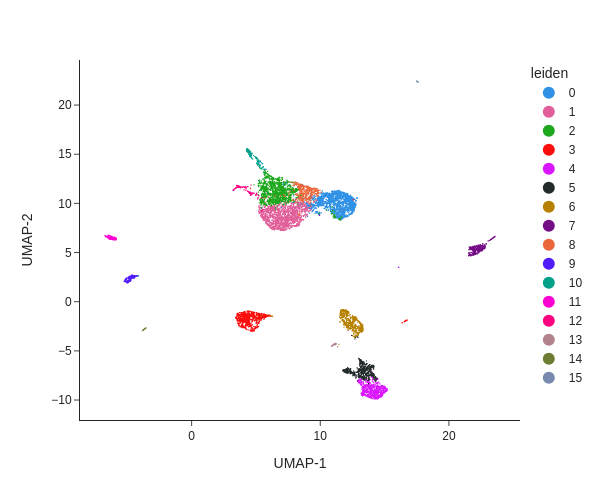

In [23]:
snap.pl.umap(data, color='leiden', interactive=False, height=500)

2026-07-03 12:53:41 - INFO - TemporaryDirectory.cleanup() worked.
2026-07-03 12:53:41 - INFO - shutil.rmtree worked.


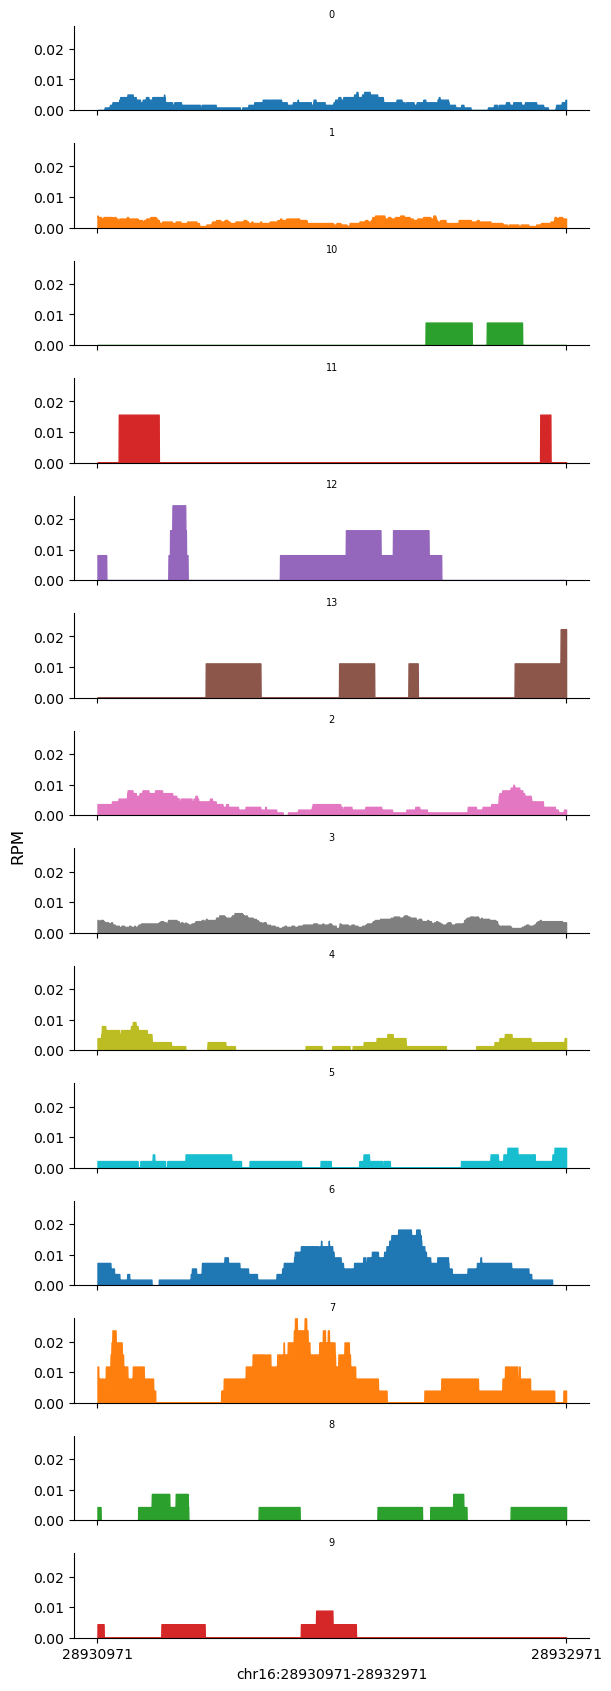

In [ ]:
#Visualise accesibility of promoter regions of marker genes, below is plotted the coverage centered around the TSS of CD19, a B marker gene
snap.pl.coverage(data, region='chr16:28930971-28932971', groupby='leiden')


In [5]:
print(data)
print(data.obsm.keys())
print(data.layers.keys())

AnnData object with n_obs × n_vars = 8415 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'total_variant_count', 'total_mt_reads'
    var: 'count', 'selected'
    uns: 'TSS_profile', 'doublet_rate', 'frac_overlap_TSS', 'frag_size_distr', 'library_tsse', 'reference_sequences', 'scrublet_sim_doublet_score', 'spectral_eigenvalue', 'variant_names', 'variant_summary'
    obsm: 'X_spectral', 'X_umap', 'coverage_per_cell', 'fragment_paired', 'variant_confident', 'variant_counts', 'variant_vaf'
    obsp: 'distances'
KeysView(AxisArrays with keys: X_spectral, X_umap, coverage_per_cell, fragment_paired, variant_confident, variant_counts, variant_vaf)
KeysView(Layers with keys: )


In [6]:
## Annotate the clusters and assign them to known cell types
## Compute gene activities for each cell using pp.make_gene_matrix

gene_matrix = snap.pp.make_gene_matrix(data, snap.genome.hg38)
gene_matrix

AnnData object with n_obs × n_vars = 8415 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'total_variant_count', 'total_mt_reads'

In [7]:
### The cell by gene activity matrix is sparse
## The MAGIC algorithm performs imputation and data smoothing
## Then scanpy does subsequent steps 
## First perform gene filtering, normalisation and transformation and then call MAGIC
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
# Skip MAGIC imputation - the analysis will work fine without it
sc.external.pp.magic(gene_matrix, solver="approximate")

# Copy over UMAP embedding
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]

In [8]:
#load the AnnData object into memory, so that it can be used by scanpy and scvi-tools.
reference = snap.read(snap.datasets.pbmc10k_multiome(), backed=None)
reference
#make gene activity matrix for the reference dataset
atac = snap.read(snap.datasets.pbmc5k(type='h5ad'), backed=None)
query = snap.pp.make_gene_matrix(atac, gene_anno=snap.genome.hg38)
query

AnnData object with n_obs × n_vars = 4430 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden'

In [9]:
#merge reference data and query data together and use the scanpy library to find out highly variable genes.
query.obs['cell_type'] = pd.NA
data = ad.concat(
    [reference, query],
    join='inner',
    label='batch',
    keys=["reference", "query"],
    index_unique='_',
)
#create gene matrix and filer out highly variable genes
sc.pp.filter_genes(data, min_cells=5)
sc.pp.highly_variable_genes(
    data,
    n_top_genes = 5000,
    flavor="seurat_v3",
    batch_key="batch",
    subset=True
)

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/anndata/_core/merge.py:1349: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [ ]:
#setup scv-tools to pretrain model
scvi.settings.dl_num_workers =39
scvi.model.SCVI.setup_anndata(data, batch_key="batch")
vae = scvi.model.SCVI(
    data,
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb",
    dispersion="gene-batch",
)
vae.train(max_epochs=500, early_stopping=True)
ax = vae.history['elbo_train'][1:].plot()
vae.history['elbo_validation'].plot(ax=ax)lvae.save("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_surg_blood/final_model", overwrite=True)

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env190516/lib/pyth ...
INFO: GPU available: False, used: False
2026-07-03 17:22:01 - INFO - GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
2026-07-03 17:22:01 - INFO - TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-03 17:22:01 - INFO - 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs

Epoch 10/500:   2%|▏         | 9/500 [15:47<14:22:33, 105.40s/it, v_num=1, train_loss_step=2.16e+3, train_loss_epoch=2.18e+3]

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
2026-07-03 17:38:16 - INFO - 
Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [6]:
#Get peaks using MACS3, which will be stored in data.uns['macs3']
snap.tl.macs3(data, groupby='leiden')
#Create a unified, non-overlapping, and fixed-width peak list 
peaks = snap.tl.merge_peaks(data.uns['macs3'], snap.genome.hg38)
peaks.head()
#Creating a peak matrix
peak_mat = snap.pp.make_peak_matrix(data, use_rep=peaks['Peaks'])
peak_mat

2026-07-05 18:06:24 - INFO - Exporting fragments...
2026-07-05 18:07:27 - INFO - Calling peaks...
100%|██████████| 16/16 [14:25<00:00, 54.07s/it] 


AnnData object with n_obs × n_vars = 8415 × 250990
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'total_variant_count', 'total_mt_reads'

2026-07-05 18:22:55 - WARNING - Input contains 117933 peaks, only 50000 peaks will be plotted.
2026-07-05 18:23:10 - INFO - [7820 MB] Chromium init'ed with kwargs {}
2026-07-05 18:23:10 - INFO - [7820 MB] Found chromium path: /home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-07-05 18:23:10 - INFO - [7820 MB] Temp directory created: /tmp/tmpvy3m81mc.
2026-07-05 18:23:10 - INFO - [7820 MB] Opening browser.
2026-07-05 18:23:10 - INFO - [7820 MB] Temp directory created: /tmp/tmpn9ku70uv.
2026-07-05 18:23:10 - INFO - [7820 MB] Temporary directory at: /tmp/tmpn9ku70uv
2026-07-05 18:23:11 - INFO - [7820 MB] Conforming 1 to file:///tmp/tmpvy3m81mc/index.html
2026-07-05 18:23:11 - INFO - [7820 MB] Waiting on all navigates
2026-07-05 18:23:13 - INFO - [7820 MB] All navigates done, putting them all in queue.
2026-07-05 18:23:13 - INFO - [7820 MB] Getting tab from queue (has 1)
2026-07-05 18:23:13 - INFO - [7820 MB] Go

CPU times: user 20.6 s, sys: 2.13 s, total: 22.7 s
Wall time: 36.9 s


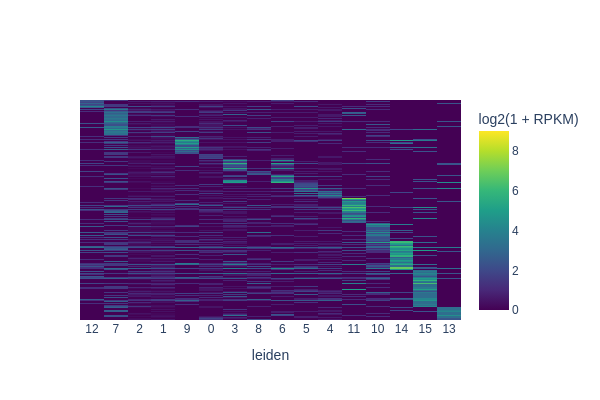

In [7]:
%%time
marker_peaks = snap.tl.marker_regions(peak_mat, groupby='leiden', pvalue=0.01)
snap.pl.regions(peak_mat, groupby='leiden', peaks=marker_peaks, interactive=False)


In [ ]:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!    mtDNA VARIANT CALLING !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [4]:
import sys
sys.path.insert(0, '/mnt/claw-raid/elliot/P002_mtscATAC-seq/scripts/Py_mTCall_tools/Py_mTCall_tools')
import variant_calling_fast as vc
mgatk = vc.process_variants_fast("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/raw/blood_epilepsy/mgatk_output/final", data, verbose=True, coverage_threshold=10, min_strand_count=2)



=== Fast Variant Calling Pipeline ===


You'll find variant names in adata.uns['variant_names']

Find coverage PER cell in adata.obsm['coverage_per_cell']

Variant summmary stats similar to Signac are in adata.uns['variant_summary']

Variant matrices are in adata.obsm["variant_vaf"]


=== IMPORTANT NOTE ===

Remember that variant VAFs are only included if they pass the min_strand_count filter

AND the coverage threshold if specified!



Loaded counts data: (132442, 10282)
Loaded coverage data: (161491709, 3)
Identifying variants (memory-optimized chunked method)...
Processing all 99238 variant observations (no artificial limits)
Integrating with AnnData...
=== Pipeline Complete ===
Processed 7355 variants in 8343 matching cells


In [5]:
mgatk.write_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/ForHPC/surgbloodmtak_cov10.h5ad")


In [3]:
mgatk = ad.read_h5ad('/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/JuneRuns/surgical_mgatk_cov10.h5ad')


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/JuneRuns/surgical_mgatk_cov10.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [11]:
import pandas as pd
import numpy as np


vaf_matrix = mgatk.obsm['variant_vaf']
coverage_matrix = mgatk.obsm['coverage_per_cell']
variant_names = pd.Index(mgatk.uns['variant_names'])


print(f"Before filtering: {len(variant_names)} variants")


H_positions = np.array([73, 263, 750, 1438, 2706, 4769, 6776, 7028, 8860, 11719, 14766, 15326, 16519])


variant_df = pd.DataFrame({
    'variant_name': variant_names.astype(str),
    'pos': variant_names.astype(str).str.split('-').str[1].astype(int)
})


variant_df = variant_df[~variant_df['pos'].isin(H_positions)].copy()
variant_df = variant_df.drop_duplicates(subset='pos', keep='first').copy()


keep_variant_idx = variant_df.index.to_numpy()


leiden_clusters_to_keep = ['1', '8', '2', '3', '9', '4', '5', '6']
keep_cells_mask = mgatk.obs['leiden'].astype(str).isin(leiden_clusters_to_keep)


conf_stats = mgatk.uns['variant_summary']


high_conf_full = conf_stats['n_cells_conf_detected'] >= 2
strand_full = conf_stats['strand_concordance'] > 0.65


combined_full = high_conf_full & strand_full
keep_variant_idx_full_mask = np.ones(len(variant_names), dtype=bool)
keep_variant_idx_full_mask[keep_variant_idx] = True


final_variant_mask = combined_full & keep_variant_idx_full_mask
keep_variant_idx = np.where(final_variant_mask)[0]


final_vars = variant_names[keep_variant_idx].to_numpy()


median_cov_per_cell = np.median(coverage_matrix, axis=1)
median_cov_mask = median_cov_per_cell >= 10
keep_cells_mask = np.asarray(keep_cells_mask & median_cov_mask)


cluster_df = pd.DataFrame({
    'leiden': mgatk.obs['leiden'].astype(str),
    'keep': keep_cells_mask
})
retained = cluster_df.groupby('leiden')['keep'].agg(['sum', 'count'])
retained['pct_retained'] = 100 * retained['sum'] / retained['count']


print("\n% cells retained in each cluster:")
print(retained)


vaf_subset = vaf_matrix[keep_cells_mask][:, keep_variant_idx]
cov_subset = coverage_matrix[keep_cells_mask][:, keep_variant_idx]


# NO site support filter — keep for union with other tissue


signal_keep = (vaf_subset > 0).any(axis=0)
vaf_final = vaf_subset[:, signal_keep]
final_vars = final_vars[signal_keep]
final_cells = mgatk.obs.index[keep_cells_mask]


final_cell_names = ['P_' + mgatk.obs.loc[cell, 'leiden'] + '_' + cell for cell in final_cells]


final_matrix = pd.DataFrame(
    vaf_final,
    index=final_cell_names,
    columns=final_vars
)


variant_positions = pd.Index(final_matrix.columns).str.split('-').str[1].astype(int)


print(f"\n=== Final Matrix with Prefixed Barcodes ===")
print(f"Shape: {final_matrix.shape}")
print(f"Final cells: {final_matrix.shape[0]}")
print(f"Final variants: {final_matrix.shape[1]}")
print(f"True number of variants: {variant_positions.nunique()}")
print(f"Duplicate positions: {variant_positions.duplicated().sum()}")


# Diagnostics
cells_per_variant = (final_matrix > 0).sum(axis=0)
print(f"\n=== Diagnostics ===")
print(f"Min cells per variant: {cells_per_variant.min()}")
print(f"Max cells per variant: {cells_per_variant.max()}")
print(f"All variants in >= 2 cells: {(cells_per_variant >= 2).all()}")
print(f"1-cell variants: {(cells_per_variant == 1).sum()}")
print(f"2-cell variants: {(cells_per_variant == 2).sum()}")
print(f"3+ cell variants: {(cells_per_variant >= 3).sum()}")
print(f"Duplicate positions: {variant_positions.duplicated().sum()}")
sparsity = 100 * (final_matrix == 0).sum().sum() / (final_matrix.shape[0] * final_matrix.shape[1])
print(f"Sparsity: {sparsity:.1f}% zeros")

Before filtering: 7355 variants

% cells retained in each cluster:
         sum  count  pct_retained
leiden                           
0          0   1609      0.000000
1       1101   1336     82.410180
10         0    166      0.000000
11         0    142      0.000000
12         0    138      0.000000
13         0     74      0.000000
14         0     51      0.000000
15         0     47      0.000000
2        938   1136     82.570423
3        668    836     79.904306
4        556    690     80.579710
5        495    616     80.357143
6        500    595     84.033613
7          0    413      0.000000
8        331    394     84.010152
9        139    172     80.813953

=== Final Matrix with Prefixed Barcodes ===
Shape: (4728, 2681)
Final cells: 4728
Final variants: 2681
True number of variants: 2651
Duplicate positions: 30

=== Diagnostics ===
Min cells per variant: 1
Max cells per variant: 4665
All variants in >= 2 cells: False
1-cell variants: 1040
2-cell variants: 986
3+ cell vari

In [12]:
# Save the final matrix
final_matrix.to_csv('/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/JuneRuns/Blood_matrix_nonunion.csv')

In [14]:
import pandas as pd
import numpy as np

# Load union variant list
union_vars_df = pd.read_csv(
    "/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/JuneRuns/union_vars.csv",
    header=None
)
union_vars = union_vars_df.iloc[:, 0].astype(str).tolist()

# Build coverage matrix from mgatk
cov_df = pd.DataFrame(
    data=mgatk.obsm['coverage_per_cell'],
    index=mgatk.obs.index.astype(str),
    columns=pd.Index(mgatk.uns['variant_names']).astype(str)
)

# Use union vars that exist in both brain matrices
blood_vars = [v for v in union_vars if v in final_matrix.columns and v in cov_df.columns]
print(f"Variants in union, blood VAF, and coverage: {len(blood_vars)}")

# Brain cells
blood_cells = final_matrix.index.astype(str)
blood_cells_raw = blood_cells.to_series().str.split('_').str[-1]

# Subset coverage and VAF
cov_sub = cov_df.loc[blood_cells_raw.values, blood_vars].copy()
cov_sub.index = blood_cells

vaf_sub = final_matrix.loc[blood_cells, blood_vars].copy()

# Long format
long_df_final = cov_sub.stack().reset_index()
long_df_final.columns = ['cell', 'variant', 'd']

vaf_long = vaf_sub.stack().reset_index()
vaf_long.columns = ['cell', 'variant', 'vaf']

long_df_final = long_df_final.merge(vaf_long, on=['cell', 'variant'], how='left')
long_df_final['a'] = (long_df_final['vaf'] * long_df_final['d']).round().fillna(0).astype(int)

long_df_final = long_df_final[['cell', 'variant', 'a', 'd']].reset_index(drop=True)

# Save
out_path = "/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/JuneRuns/blood_long_union.csv"
long_df_final.to_csv(out_path, index=False)

# Diagnostics
print(f"FINAL: {long_df_final['cell'].nunique()} cells × {long_df_final['variant'].nunique()} variants")
print(long_df_final.head())
print(f"Saved to: {out_path}")

Variants in union, blood VAF, and coverage: 2681
FINAL: 4728 cells × 2681 variants
                     cell    variant  a     d
0  P_2_AAACGAAAGATCCGAG-1  A-10029-G  0  28.0
1  P_2_AAACGAAAGATCCGAG-1  A-10161-G  0  74.0
2  P_2_AAACGAAAGATCCGAG-1  A-10183-G  0  95.0
3  P_2_AAACGAAAGATCCGAG-1  A-10232-G  0  46.0
4  P_2_AAACGAAAGATCCGAG-1  A-10372-G  0  55.0
Saved to: /mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/JuneRuns/blood_long_union.csv


In [ ]:
#Filter vars per tissue BEFORE making long matrix with untion list 
import pandas as pd

vaf_matrix = mgatk.obsm['variant_vaf']
cell_names = mgatk.obs.index
variant_names = pd.Index(mgatk.uns['variant_names'])

# Leiden cell filter
leiden_clusters_to_keep = ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15']  # Adjust based on your clusters of interest
keep_cells_mask = mgatk.obs['leiden'].isin(leiden_clusters_to_keep)
keep_cells = mgatk.obs.index[keep_cells_mask]

print(f"Cells BEFORE leiden filter: {len(cell_names)}")
print(f"Cells AFTER leiden filter:  {len(keep_cells)}")

# Filter matrices to leiden cells
vaf_leiden = vaf_matrix[keep_cells_mask]
cov_leiden = mgatk.obsm['coverage_per_cell'][keep_cells_mask]

# *** FIXED: Combined mask - leiden signal AND high confidence ***
conf_stats = mgatk.uns['variant_summary']
high_conf_mask = conf_stats['n_cells_conf_detected'] >= 2

# Leiden-specific signal in high-conf vars only
leiden_signal_in_conf = (vaf_leiden[:, high_conf_mask] > 0).any(axis=0)
leiden_high_conf_vars = variant_names[high_conf_mask][leiden_signal_in_conf]

print(f"High-conf variants total:     {high_conf_mask.sum()}")
print(f"High-conf + leiden signal:   {len(leiden_high_conf_vars)}")



Cells BEFORE leiden filter: 8415
Cells AFTER leiden filter:  8415
High-conf variants total:     3056
High-conf + leiden signal:   2981


In [8]:
#load in union vars
union_vars = pd.read_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/CatRun210526/union_vars.csv",
                         header=None)[0].astype(str).tolist()

In [9]:
import numpy as np
#build matrix with union vars
# Build matrices using union_vars
union_mask = np.isin(variant_names, union_vars)
final_variants = np.array(variant_names)[union_mask]

overall_coverage_df = pd.DataFrame(
    data=cov_leiden[:, union_mask],
    index=keep_cells,
    columns=final_variants
)

phylogeny_df = pd.DataFrame(
    data=vaf_leiden[:, union_mask],
    index=keep_cells,
    columns=final_variants
)

# Median depth filter per cell
coverage_final = overall_coverage_df.values
median_d_final = np.median(coverage_final, axis=1)
good_cells_mask = median_d_final >= 10
keep_cells_final = overall_coverage_df.index[good_cells_mask]

print(f"Cells AFTER median_d >= 10 filter: {len(keep_cells_final)} / {len(keep_cells)}")

# Direct long table with all cell × variant pairs
cov_sub = overall_coverage_df.loc[keep_cells_final]
vaf_sub = phylogeny_df.loc[keep_cells_final]

long_df_final = (
    cov_sub.stack().reset_index()
    .rename(columns={'level_0': 'cell', 'level_1': 'variant', 0: 'd'})
)

long_df_final['a'] = (vaf_sub.stack().reset_index(drop=True) * long_df_final['d']).round().astype(int)
long_df_final = long_df_final[['cell', 'variant', 'a', 'd']]

# Haplogroup filter
haplogroup_positions = ['73', '263', '750', '1438', '2706', '4769', '7028', '8860',
                        '11719', '14766', '15326', '16519', '6776']

long_df_final = long_df_final[
    ~long_df_final['variant'].astype(str).str.contains('|'.join(haplogroup_positions), regex=True)
].reset_index(drop=True)

print(f"FINAL: {long_df_final['cell'].nunique()} cells × {long_df_final['variant'].nunique()} variants")
long_df_final.to_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/CatRun210526/blood_long_union.csv", index=False)

Cells AFTER median_d >= 10 filter: 6859 / 8415
FINAL: 6859 cells × 1613 variants


In [ ]:
import pandas as pd

# 1. Load data
df_cortex = pd.read_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDriftMaster/Cortex_surgical_long_variant_matrix.csv")
df_pbmc = pd.read_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDriftMaster/PBMC_surgical_long_variant_matrix.csv")


# 3. Now concatenate
combined_df = pd.concat([df_cortex, df_pbmc], ignore_index=True)

# 4. Save
combined_df.to_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDriftMaster/Combined_Surgical_Lineage_Matrix.csv", index=False)

print(f"Concatenated with unique prefixes: {len(combined_df)} total rows.")

Concatenated with unique prefixes: 11196354 total rows.


In [ ]:

## You can look for variant info in UNS
print(mgatk.uns['variant_summary'])

# Strand concordance is the correlation of the number of reads in each strand
strand_concordance = mgatk.uns['variant_summary']['mean_coverage']
# N cells over 5 is the number of cells with more than 5 reads supporting the variant
n_cells_over_5 = mgatk.uns['variant_summary']['n_cells_over_5']
# Variance is the variance of the number of reads supporting the variant across cells
variance = mgatk.uns['variant_summary']['n_cells_conf_detected']



print(strand_concordance)
print(n_cells_over_5)
print(variance)

# Find variants with high strand concordance and sufficient cell coverage
# You can adjust the thresholds based on your analysis needs
high_quality_variants = mgatk.uns['variant_summary'][
    #(mgatk.uns['variant_info']['strand_concordance'] >= 0.2) & 
    (mgatk.uns['variant_summary']['n_cells_over_5'] >= 2) & 
    #(mgatk.uns['variant_info']['variance'] >= 0.001) &
    (mgatk.uns['variant_summary']['mean_coverage'] >= 10)
]
print(high_quality_variants.index)
print(len(high_quality_variants))
print(len(mgatk.uns['variant_summary']), "Number of unfiltered variants")


          mean      variance  n_cells_conf_detected  n_cells_over_5  \
0     0.000029  3.951452e-06                      1               1   
1     0.000090  1.606980e-05                      2               2   
2     0.000482  2.378333e-04                      3               3   
3     0.000138  2.603129e-05                      1               1   
4     0.000031  1.867679e-06                      1               1   
...        ...           ...                    ...             ...   
4705  0.000021  7.965443e-07                      1               1   
4706  0.000027  1.475697e-06                      1               1   
4707  0.000031  2.439417e-06                      1               1   
4708  0.000017  1.670454e-07                      1               0   
4709  0.000018  1.328127e-07                      1               0   

      n_cells_over_10  n_cells_over_50  mean_coverage  strand_concordance  \
0                   1                0      24.707472            1.000

In [ ]:
vaf_matrix = mgatk.obsm['variant_vaf']

cell_names = mgatk.obs.index
variant_names = mgatk.uns['variant_names']

# Build overall coverage dataframe
overall_coverage_df = pd.DataFrame(
    data=mgatk.obsm['coverage_per_cell'],
    index=cell_names,
    columns=variant_names)

# Build VAF dataframe
phylogeny_df = pd.DataFrame(
    data=vaf_matrix,
    index=cell_names,
    columns=variant_names)

# Calculate alternate allele counts: a = vaf * coverage (rounded to int)
alt_counts_df = phylogeny_df.mul(overall_coverage_df, fill_value=0).round().astype(int)

# Filter to variants with at least one cell having a positive call
active_variants = alt_counts_df.sum(axis=0)
active_variants = active_variants[active_variants > 0].index

alt_counts_df_filtered = alt_counts_df[active_variants]
coverage_df_filtered = overall_coverage_df[active_variants]

# Melt both to long format
alt_long = alt_counts_df_filtered.reset_index().melt(id_vars='index', var_name='variant', value_name='a')
cov_long = coverage_df_filtered.reset_index().melt(id_vars='index', var_name='variant', value_name='d')

# Combine into single dataframe
long_df = alt_long.copy()
long_df['d'] = cov_long['d'].round().astype(int)
long_df = long_df.rename(columns={'index': 'cell'})

# Reorder columns
long_df = long_df[['cell', 'variant', 'a', 'd']]

print(long_df.head(10))
long_df.to_csv("outs/PBMC_PM_long_variant_matrix.csv", index=False)

In [ ]:
# Validate the ultra-fast variant calling results
print("=== Ultra-Fast Variant Calling Results ===")
print(f"Total variants processed: {len(mgatk.uns['variant_names'])}")
print(f"Variant data stored in mgatk.obsm with keys: {list(mgatk.obsm.keys())}")
print(f"Summary data keys: {list(mgatk.uns['variant_summary'].columns)}")

# Get the matrices from AnnData
vaf_matrix = mgatk.obsm['variant_vaf']  # Shape: (cells, variants)
coverage_matrix = mgatk.obsm['variant_coverage']  # Shape: (cells, variants)
confident_matrix = mgatk.obsm['variant_confident']  # Shape: (cells, variants)
variant_names = mgatk.uns['variant_names']

print(f"\nMatrix shapes:")
print(f"  VAF matrix: {vaf_matrix.shape}")
print(f"  Coverage matrix: {coverage_matrix.shape}")
print(f"  Confident matrix: {confident_matrix.shape}")

# Filter for high-quality variants
high_quality_variants = mgatk.uns['variant_summary'][
    (mgatk.uns['variant_summary']['n_cells_over_5'] >= 2) & 
    (mgatk.uns['variant_summary']['mean_coverage'] >= 10)
]

print(f"\nHigh-quality variants: {len(high_quality_variants)}")
print(f"High-quality variant indices: {high_quality_variants.index[:10].tolist()}")  # Show first 10

# Validate confident calls for first few high-quality variants
print("\n=== Validation: Checking confident calls ===")
for i, variant_idx in enumerate(high_quality_variants.index[:3]):  # Check first 3
    print(f"\nVariant {i+1} (index {variant_idx}):")
    print(f"  Variant name: {variant_names[variant_idx]}")
    
    # Get data for this variant (all cells)
    vaf_values = vaf_matrix[:, variant_idx]
    coverage_values = coverage_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Get cells with confident calls and non-zero VAF
    confident_mask = confident_calls & (vaf_values > 0)
    
    if confident_mask.any():
        conf_vaf = vaf_values[confident_mask]
        conf_cov = coverage_values[confident_mask]
        
        # Calculate variant reads = VAF * coverage
        variant_reads = conf_vaf * conf_cov
        
        print(f"  Confident cells: {confident_mask.sum()}")
        print(f"  Coverage range: {conf_cov.min():.1f} - {conf_cov.max():.1f}")
        print(f"  VAF range: {conf_vaf.min():.3f} - {conf_vaf.max():.3f}")
        print(f"  Variant reads range: {variant_reads.min():.1f} - {variant_reads.max():.1f}")
        print(f"  All coverage >= 2: {(conf_cov >= 2).all()}")
        print(f"  All variant reads >= 2: {(variant_reads >= 2).all()}")
    else:
        print(f"  No confident cells found")

=== Ultra-Fast Variant Calling Results ===
Total variants processed: 4710
Variant data stored in mgatk.obsm with keys: ['X_umap', 'variant_vaf', 'variant_counts', 'variant_coverage', 'variant_confident']
Summary data keys: ['mean', 'variance', 'n_cells_conf_detected', 'n_cells_over_5', 'n_cells_over_10', 'n_cells_over_50', 'mean_coverage', 'strand_concordance', 'vaf_overall']

Matrix shapes:
  VAF matrix: (7626, 4710)
  Coverage matrix: (7626, 4710)
  Confident matrix: (7626, 4710)

High-quality variants: 1437
High-quality variant indices: [1, 2, 6, 7, 11, 12, 24, 26, 27, 28]

=== Validation: Checking confident calls ===

Variant 1 (index 1):
  Variant name: A-10726-G
  Confident cells: 2
  Coverage range: 12.0 - 72.0
  VAF range: 0.153 - 0.333
  Variant reads range: 4.0 - 11.0
  All coverage >= 2: True
  All variant reads >= 2: True

Variant 2 (index 2):
  Variant name: A-11163-G
  Confident cells: 1
  Coverage range: 68.0 - 68.0
  VAF range: 0.941 - 0.941
  Variant reads range: 64.0 

In [ ]:
# Define confident variants (those with at least one cell having ≥2 reads on both strands)
confident_variant_names = mgatk.uns['variant_summary'][mgatk.uns['variant_summary']['n_cells_conf_detected'] > 0].index.tolist()

# Show breakdown of confident vs total variants
print(f"Total variants: {len(mgatk.uns['variant_names'])}")
print(f"Confident variants: {len(confident_variant_names)}")
print(f"Percentage confident: {len(confident_variant_names)/len(mgatk.uns['variant_names'])*100:.1f}%")

# Explain what "confident" means
print(f"\nConfident detection criteria:")
print(f"- At least 2 reads supporting the variant on the forward strand")
print(f"- At least 2 reads supporting the variant on the reverse strand") 
print(f"- This must be true in at least one cell")
print(f"\nSo YES - all {len(confident_variant_names)} confident variants have at least 2 calls on each strand in at least one cell")

Total variants: 4710
Confident variants: 4710
Percentage confident: 100.0%

Confident detection criteria:
- At least 2 reads supporting the variant on the forward strand
- At least 2 reads supporting the variant on the reverse strand
- This must be true in at least one cell

So YES - all 4710 confident variants have at least 2 calls on each strand in at least one cell


Plotting first 5 confident variants out of 4710 total confident variants
Processing variant 1: Index 0, Name: A-10172-G


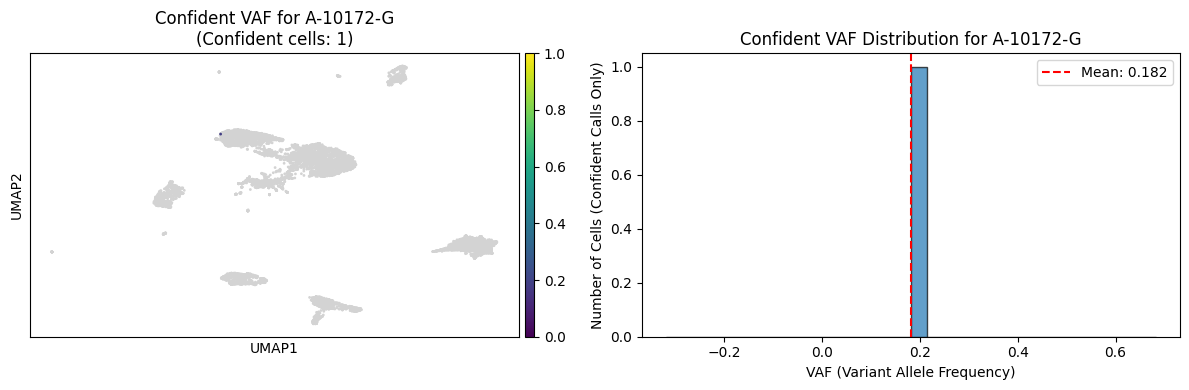

Variant A-10172-G (Index 0):
  Confident cells detected: 1
  Mean coverage: 24.7
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.182
  Confident VAF range: 0.182 - 0.182
---
Processing variant 2: Index 1, Name: A-10726-G


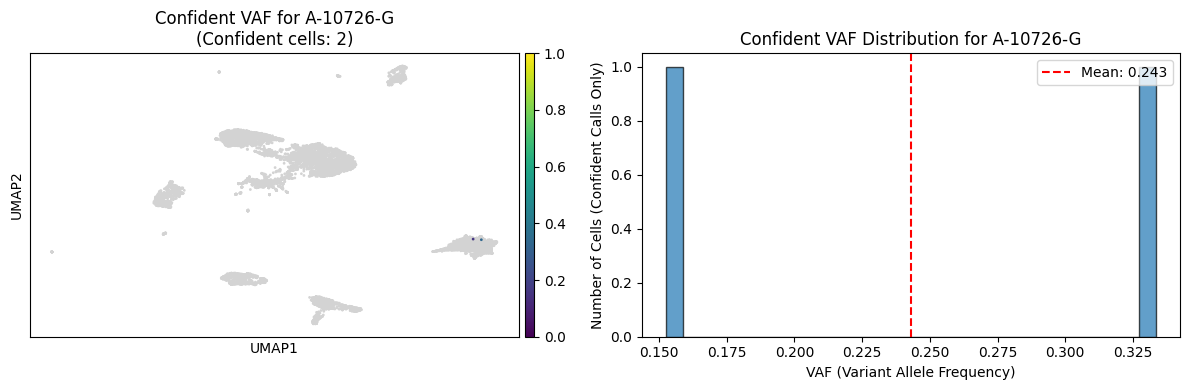

Variant A-10726-G (Index 1):
  Confident cells detected: 2
  Mean coverage: 20.0
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 2
  Mean confident VAF: 0.243
  Confident VAF range: 0.153 - 0.333
---
Processing variant 3: Index 2, Name: A-11163-G


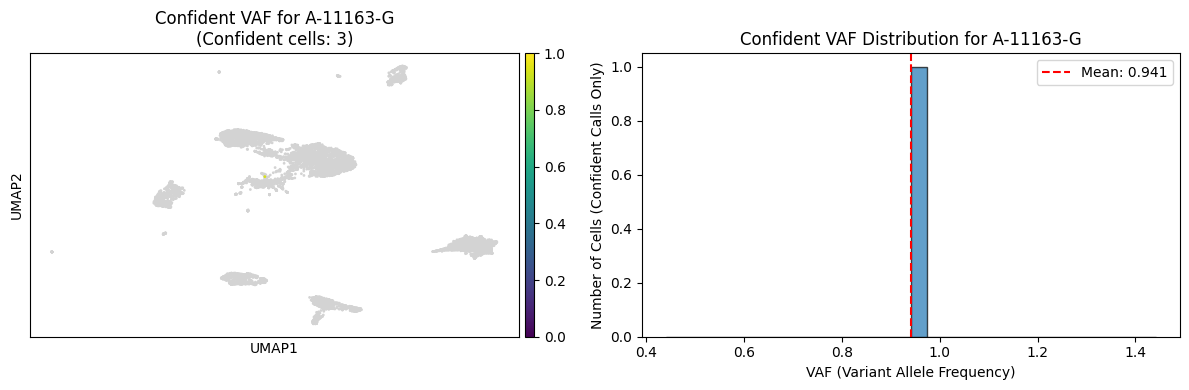

Variant A-11163-G (Index 2):
  Confident cells detected: 3
  Mean coverage: 30.0
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.941
  Confident VAF range: 0.941 - 0.941
---
Processing variant 4: Index 3, Name: A-11225-G
No confident non-zero calls for variant A-11225-G
Processing variant 5: Index 4, Name: A-11382-C


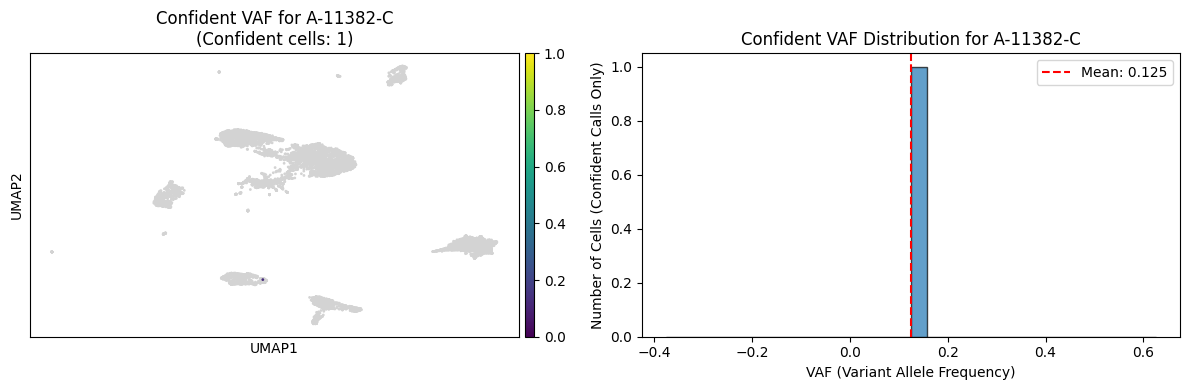

Variant A-11382-C (Index 4):
  Confident cells detected: 1
  Mean coverage: 15.6
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.125
  Confident VAF range: 0.125 - 0.125
---


In [ ]:
# Plot confident variants with UMAP and VAF distribution
import matplotlib.pyplot as plt
import numpy as np

# Get confident variants (those with at least one cell having confident detection)
confident_variants = mgatk.uns['variant_summary'][mgatk.uns['variant_summary']['n_cells_conf_detected'] > 0]

print(f"Plotting first 5 confident variants out of {len(confident_variants)} total confident variants")

# Get the variant names list
variant_names = mgatk.uns['variant_names']

for i, variant_idx in enumerate(confident_variants.index[:5]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    
    print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")
    
    # Get VAF and confident matrices
    vaf_matrix = mgatk.obsm['variant_vaf']
    confident_matrix = mgatk.obsm['variant_confident']
    
    # Extract VAF and confidence for this specific variant using the integer index
    vaf_values = vaf_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Filter for confident calls AND non-zero VAF
    confident_and_nonzero_mask = confident_calls & (vaf_values > 0)
    
    if not confident_and_nonzero_mask.any():
        print(f"No confident non-zero calls for variant {variant_name}")
        continue
    
    # Get filtered VAF values
    filtered_vaf_values = vaf_values[confident_and_nonzero_mask]
    
    # Create a temporary column for plotting (confident calls only)
    temp_vaf_col = np.zeros(len(mgatk.obs))
    temp_vaf_col[confident_and_nonzero_mask] = filtered_vaf_values
    # Set non-confident or zero calls to NaN for proper plotting
    temp_vaf_col[~confident_and_nonzero_mask] = np.nan
    
    # Add temporary column to obs for plotting
    mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # UMAP plot (only confident calls will be colored)
    sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1, 
               title=f"Confident VAF for {variant_name}\n(Confident cells: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']})", 
               ax=ax1, show=False, na_color='lightgray')
    
    # Histogram of confident VAF values only
    ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('VAF (Variant Allele Frequency)')
    ax2.set_ylabel('Number of Cells (Confident Calls Only)')
    ax2.set_title(f'Confident VAF Distribution for {variant_name}')
    ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
                label=f'Mean: {filtered_vaf_values.mean():.3f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_cells = len(mgatk.obs)
    confident_cells = confident_calls.sum()
    confident_nonzero_cells = len(filtered_vaf_values)
    
    print(f"Variant {variant_name} (Index {variant_idx}):")
    print(f"  Confident cells detected: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']}")
    print(f"  Mean coverage: {confident_variants.loc[variant_idx, 'mean_coverage']:.1f}")
    print(f"  Total cells: {total_cells}")
    print(f"  Confident calls: {confident_calls}")
    print(f"  Confident non-zero calls: {confident_nonzero_cells}")
    print(f"  Mean confident VAF: {filtered_vaf_values.mean():.3f}")
    print(f"  Confident VAF range: {filtered_vaf_values.min():.3f} - {filtered_vaf_values.max():.3f}")
    print("---")
    
    # Clean up temporary column
    mgatk.obs.drop(columns=[f'temp_vaf_{variant_idx}'], inplace=True)

Variant A-10172-G: Insufficient data points (1)
Variant A-10726-G: Insufficient data points (2)
Variant A-11163-G: Insufficient data points (1)
Variant A-11225-G: Insufficient data points (0)
Variant A-11382-C: Insufficient data points (1)
Variant A-11415-C: Insufficient data points (1)


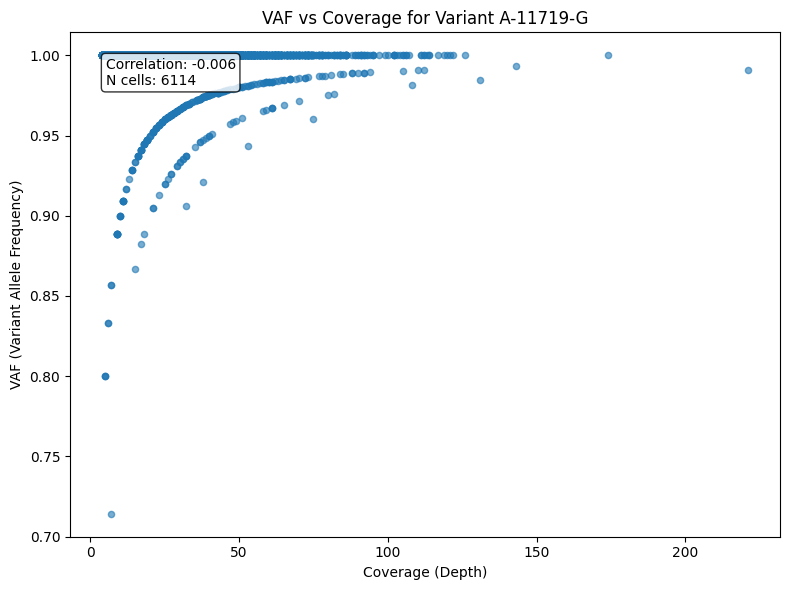

Variant A-11719-G:
  Coverage range: 4.0 - 221.0
  Mean coverage: 25.3
  VAF range: 0.714 - 1.000
  Correlation (VAF vs Coverage): -0.006
---


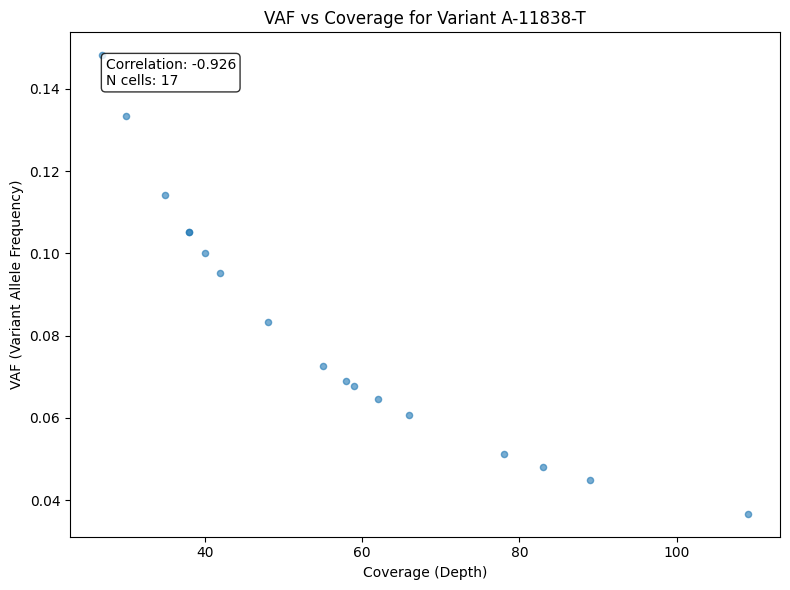

Variant A-11838-T:
  Coverage range: 27.0 - 109.0
  Mean coverage: 56.3
  VAF range: 0.037 - 0.148
  Correlation (VAF vs Coverage): -0.926
---
Variant A-11858-C: Insufficient data points (1)
Variant A-1204-C: Insufficient data points (1)
Variant A-12412-C: Insufficient data points (1)


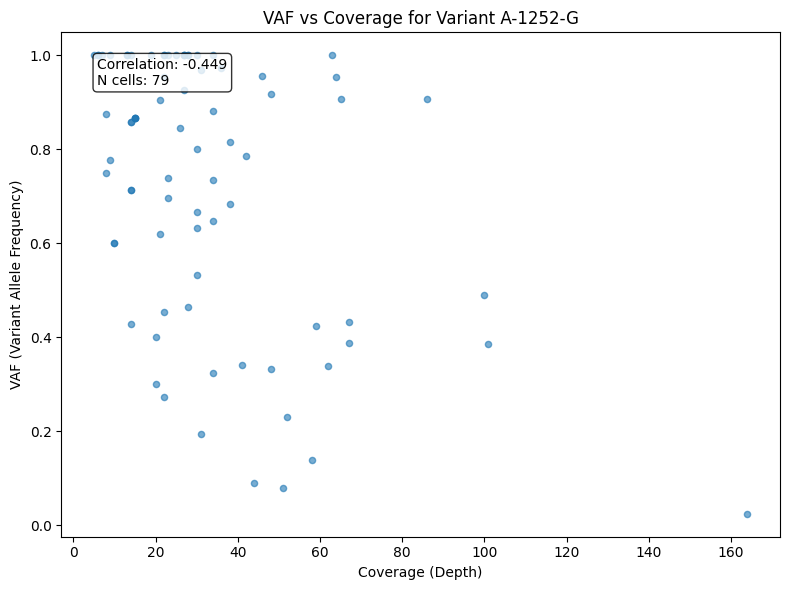

Variant A-1252-G:
  Coverage range: 5.0 - 164.0
  Mean coverage: 32.8
  VAF range: 0.024 - 1.000
  Correlation (VAF vs Coverage): -0.449
---
Variant A-12583-G: Insufficient data points (2)
Variant A-12861-C: Insufficient data points (1)
Variant A-13043-C: Insufficient data points (1)
Variant A-13094-T: Insufficient data points (0)
Variant A-13329-C: Insufficient data points (1)
Variant A-13558-G: Insufficient data points (1)
Variant A-13694-C: Insufficient data points (1)
Variant A-13730-G: Insufficient data points (1)
Variant A-13879-T: Insufficient data points (1)
Variant A-14721-G: Insufficient data points (1)
Variant A-1476-G: Insufficient data points (2)
Variant A-14991-T: Insufficient data points (0)
Variant A-15093-G: Insufficient data points (3)
Variant A-15170-G: Insufficient data points (0)
Variant A-15301-G: Insufficient data points (3)
Variant A-15708-G: Insufficient data points (4)


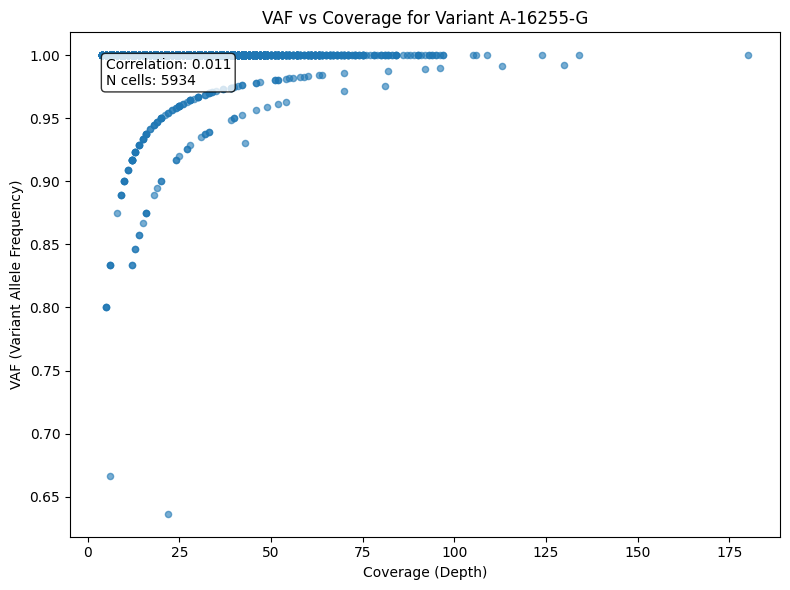

Variant A-16255-G:
  Coverage range: 4.0 - 180.0
  Mean coverage: 20.7
  VAF range: 0.636 - 1.000
  Correlation (VAF vs Coverage): 0.011
---


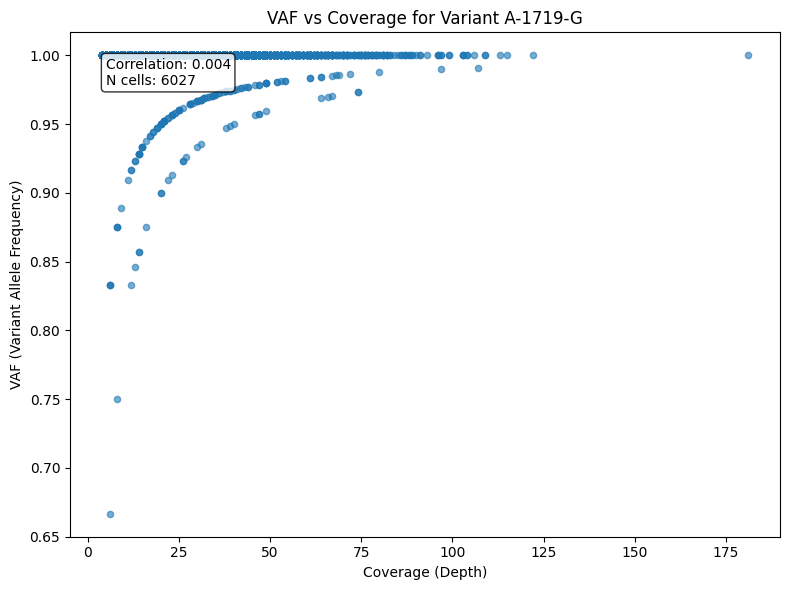

Variant A-1719-G:
  Coverage range: 4.0 - 181.0
  Mean coverage: 23.1
  VAF range: 0.667 - 1.000
  Correlation (VAF vs Coverage): 0.004
---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the matrices and variant info
vaf_matrix = mgatk.obsm['variant_vaf']        # cells x variants
coverage_matrix = mgatk.obsm['variant_coverage']  # cells x variants  
variant_names = mgatk.uns['variant_names']

# For variants in your confident_variants
for i, variant_idx in enumerate(confident_variants.index[:30]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    try:
        variant_idx = confident_variants.index[i]  # Get the actual variant index
        # Find the index of this variant in the variant_names list
        variant_idx = variant_names.index(variant_name)
        
        # Get VAF and coverage values for this variant across all cells
        vaf_values = vaf_matrix[:, variant_idx]
        coverage_values = coverage_matrix[:, variant_idx]
        
        # Filter for cells with non-zero VAF and valid coverage
        mask = (vaf_values > 0) & (coverage_values > 0)
        
        if mask.sum() > 5:  # Need at least 5 points for meaningful plot
            filtered_vaf = vaf_values[mask]
            filtered_coverage = coverage_values[mask]
            
            # Create scatter plot
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            scatter = ax.scatter(filtered_coverage, filtered_vaf, alpha=0.6, s=20)
            ax.set_xlabel('Coverage (Depth)')
            ax.set_ylabel('VAF (Variant Allele Frequency)')
            ax.set_title(f'VAF vs Coverage for Variant {variant_name}')
            
            # Add statistics
            if len(filtered_coverage) > 1 and len(set(filtered_coverage)) > 1:
                correlation = np.corrcoef(filtered_coverage, filtered_vaf)[0, 1]
            else:
                correlation = np.nan
                
            ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}\nN cells: {len(filtered_vaf)}', 
                    transform=ax.transAxes, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(f"Variant {variant_name}:")
            print(f"  Coverage range: {filtered_coverage.min():.1f} - {filtered_coverage.max():.1f}")
            print(f"  Mean coverage: {filtered_coverage.mean():.1f}")
            print(f"  VAF range: {filtered_vaf.min():.3f} - {filtered_vaf.max():.3f}")
            print(f"  Correlation (VAF vs Coverage): {correlation:.3f}")
            print("---")
        else:
            print(f"Variant {variant_name}: Insufficient data points ({mask.sum()})")
            
    except Exception as e:
        print(f"Error processing variant {variant_name}: {e}")

In [ ]:
# Check PTPRC expression in your gene matrix
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    expressing_cells = (ptprc_expression > 0).sum()
    total_cells = len(ptprc_expression)
    not_expressing = total_cells - expressing_cells
    
    print(f"PTPRC expression:")
    print(f"  Expressing cells: {expressing_cells} ({expressing_cells/total_cells*100:.1f}%)")
    print(f"  Not expressing: {not_expressing} ({not_expressing/total_cells*100:.1f}%)")
    print(f"  Total cells: {total_cells}")
else:
    print("PTPRC not found in gene matrix")

PTPRC expression:
  Expressing cells: 4841 (63.5%)
  Not expressing: 2785 (36.5%)
  Total cells: 7626


In [ ]:
import pandas as pd
import numpy as np

# Get variant summary data
variant_summary = mgatk.uns['variant_summary']
variant_names = mgatk.uns['variant_names']
vaf_matrix = mgatk.obsm['variant_vaf']
confident_matrix = mgatk.obsm['variant_confident']

# Create a DataFrame with variant names and summary stats
variants_df = pd.DataFrame(variant_summary)
variants_df.index = variant_names

# Recalculate statistics using ONLY confident calls
confident_stats = []
for i, variant_name in enumerate(variant_names):
    vaf_values = vaf_matrix[:, i]
    confident_calls = confident_matrix[:, i]
    
    # Only look at confident calls
    confident_vaf = vaf_values[confident_calls]
    confident_nonzero = confident_vaf[confident_vaf > 0]
    
    # Skip variants with no confident calls at all
    if confident_calls.sum() == 0:
        continue
    
    confident_stats.append({
        'variant': variant_name,
        'n_confident_cells': confident_calls.sum(),
        'n_confident_with_vaf': len(confident_nonzero),
        'n_confident_over_5': (confident_vaf >= 0.05).sum(),
        'n_confident_over_10': (confident_vaf >= 0.10).sum(),
        'mean_confident_vaf': confident_nonzero.mean() if len(confident_nonzero) > 0 else 0
    })

confident_df = pd.DataFrame(confident_stats)
confident_df.set_index('variant', inplace=True)

# Filter original variants_df to only include variants with confident calls
variants_with_confident = variants_df.loc[confident_df.index]

# Merge with confident stats
variants_df = variants_with_confident.join(confident_df)

# NOW filter using confident-only statistics
min_confident_cells = 1  # Minimum number of confident cells
min_confident_over_5 = 1  # Minimum confident cells with VAF > 5%

high_concordance_variants = variants_df[
    (variants_df['n_confident_cells'] >= min_confident_cells) &
    (variants_df['n_confident_over_5'] >= min_confident_over_5)
].copy()

# Sort by strand concordance (highest first)
high_concordance_variants = high_concordance_variants.sort_values('strand_concordance', ascending=True)

print(f"Original variants: {len(variant_names)}")
print(f"Variants with confident calls: {len(confident_df)}")
print(f"Found {len(high_concordance_variants)} high-quality variants (confident calls only)")
print(f"Concordance range: {high_concordance_variants['strand_concordance'].min():.3f} - {high_concordance_variants['strand_concordance'].max():.3f}")
print("\nTop 10 variants by strand concordance (confident calls only):")
print(high_concordance_variants[['strand_concordance', 'n_confident_cells', 'n_confident_over_5', 'n_confident_over_10']].head(10))
print(high_concordance_variants.index)

Original variants: 4710
Variants with confident calls: 4113
Found 3885 high-quality variants (confident calls only)
Concordance range: 0.362 - 1.000

Top 10 variants by strand concordance (confident calls only):
           strand_concordance  n_confident_cells  n_confident_over_5  \
variant                                                                
C-16189-T            0.362313               2840                2840   
C-16183-A            0.418435               2254                2254   
C-310-T              0.445890                660                 660   
C-11111-T            0.500000                  1                   1   
C-16172-T            0.694805                  4                   4   
A-16145-G            0.700000                  1                   1   
C-3577-A             0.700275                  4                   4   
T-16169-C            0.703297                  2                   2   
C-8291-A             0.722222                  1                   1

In [ ]:
# Split cells by PTPRC expression and analyze mitochondrial variants
import numpy as np
import pandas as pd

# Get PTPRC expression data
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    
    # Create masks for PTPRC+ and PTPRC- cells
    ptprc_positive_mask = ptprc_expression > 0
    ptprc_negative_mask = ptprc_expression == 0
    
    print(f"PTPRC+ cells: {ptprc_positive_mask.sum()}")
    print(f"PTPRC- cells: {ptprc_negative_mask.sum()}")
    print(f"Total cells: {len(ptprc_expression)}")
    
    # Get variant data
    vaf_matrix = mgatk.obsm['variant_vaf']
    variant_names = mgatk.uns['variant_names']
    
    # Analyze variants in each group
    ptprc_pos_variants = []
    ptprc_neg_variants = []
    
    for i, variant_name in enumerate(variant_names):
        vaf_values = vaf_matrix[:, i]
        
        # Count cells with variants in each group
        ptprc_pos_with_variant = ((vaf_values > 0) & ptprc_positive_mask).sum()
        ptprc_neg_with_variant = ((vaf_values > 0) & ptprc_negative_mask).sum()
        
        if ptprc_pos_with_variant > 0:
            ptprc_pos_variants.append({
                'variant': variant_name,
                'cells_with_variant': ptprc_pos_with_variant,
                'total_cells': ptprc_positive_mask.sum(),
                'percentage': ptprc_pos_with_variant / ptprc_positive_mask.sum() * 100
            })
            
        if ptprc_neg_with_variant > 0:
            ptprc_neg_variants.append({
                'variant': variant_name,
                'cells_with_variant': ptprc_neg_with_variant,
                'total_cells': ptprc_negative_mask.sum(),
                'percentage': ptprc_neg_with_variant / ptprc_negative_mask.sum() * 100
            })
    
    # Convert to DataFrames for easy viewing
    ptprc_pos_df = pd.DataFrame(ptprc_pos_variants)
    ptprc_neg_df = pd.DataFrame(ptprc_neg_variants)
    
    print(f"\n=== PTPRC+ cells (T cells) ===")
    print(f"Number of variants detected: {len(ptprc_pos_df)}")
    if len(ptprc_pos_df) > 0:
        print("Top 10 most frequent variants:")
        print(ptprc_pos_df.sort_values('cells_with_variant', ascending=False).head(10))
    
    print(f"\n=== PTPRC- cells (Non-T cells) ===")
    print(f"Number of variants detected: {len(ptprc_neg_df)}")
    if len(ptprc_neg_df) > 0:
        print("Top 10 most frequent variants:")
        print(ptprc_neg_df.sort_values('cells_with_variant', ascending=False).head(10))
    
    # Summary comparison
    print(f"\n=== SUMMARY ===")
    print(f"PTPRC+ cells: {ptprc_positive_mask.sum()} cells, {len(ptprc_pos_df)} variants detected")
    print(f"PTPRC- cells: {ptprc_negative_mask.sum()} cells, {len(ptprc_neg_df)} variants detected")
    print(f"Variants per cell ratio:")
    print(f"  PTPRC+: {len(ptprc_pos_df) / ptprc_positive_mask.sum():.3f} variants/cell")
    print(f"  PTPRC-: {len(ptprc_neg_df) / ptprc_negative_mask.sum():.3f} variants/cell")
    
else:
    print("PTPRC not found in gene matrix")

PTPRC+ cells: 4841
PTPRC- cells: 2785
Total cells: 7626

=== PTPRC+ cells (T cells) ===
Number of variants detected: 3134
Top 10 most frequent variants:
        variant  cells_with_variant  total_cells  percentage
3040    G-750-A                4235         4841   87.481925
3103   G-2706-a                4223         4841   87.234043
3087  G-13966-A                4205         4841   86.862219
2692  G-15326-A                4180         4841   86.345796
3130   G-8860-A                4180         4841   86.345796
929    C-6221-T                4139         4841   85.498864
2     A-11719-G                4122         4841   85.147697
2970   G-1438-A                4117         4841   85.044412
1657   T-6371-C                4094         4841   84.569304
15     A-1719-G                4063         4841   83.928940

=== PTPRC- cells (Non-T cells) ===
Number of variants detected: 1659
Top 10 most frequent variants:
        variant  cells_with_variant  total_cells  percentage
1643   G-2706-

In [ ]:
# Split cells by PTPRC expression and analyze HIGH CONCORDANCE mitochondrial variants
import numpy as np
import pandas as pd


# Get PTPRC expression data
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    
    # Create masks for PTPRC+ and PTPRC- cells
    ptprc_positive_mask = ptprc_expression > 0
    ptprc_negative_mask = ptprc_expression == 0
    
    print(f"PTPRC+ cells: {ptprc_positive_mask.sum()}")
    print(f"PTPRC- cells: {ptprc_negative_mask.sum()}")
    print(f"Total cells: {len(ptprc_expression)}")
    
    # Get variant data - but ONLY use high concordance variants
    vaf_matrix = mgatk.obsm['variant_vaf']
    variant_names = mgatk.uns['variant_names']
    
    # Filter to only high concordance variants from earlier analysis
    high_concordance_variant_names = high_concordance_variants.index.tolist()
    print(f"\nUsing {len(high_concordance_variant_names)} high concordance variants (vs {len(variant_names)} total variants)")
    
    # Get indices of high concordance variants
    high_concordance_indices = [i for i, name in enumerate(variant_names) if name in high_concordance_variant_names]
    
    # Analyze variants in each group - ONLY high concordance variants
    ptprc_pos_variants = []
    ptprc_neg_variants = []
    
    for i in high_concordance_indices:
        variant_name = variant_names[i]
        vaf_values = vaf_matrix[:, i]
        
        # Count cells with variants in each group
        ptprc_pos_with_variant = ((vaf_values > 0) & ptprc_positive_mask).sum()
        ptprc_neg_with_variant = ((vaf_values > 0) & ptprc_negative_mask).sum()
        
        if ptprc_pos_with_variant > 0:
            ptprc_pos_variants.append({
                'variant': variant_name,
                'cells_with_variant': ptprc_pos_with_variant,
                'total_cells': ptprc_positive_mask.sum(),
                'percentage': ptprc_pos_with_variant / ptprc_positive_mask.sum() * 100,
                'strand_concordance': high_concordance_variants.loc[variant_name, 'strand_concordance']
            })
            
        if ptprc_neg_with_variant > 0:
            ptprc_neg_variants.append({
                'variant': variant_name,
                'cells_with_variant': ptprc_neg_with_variant,
                'total_cells': ptprc_negative_mask.sum(),
                'percentage': ptprc_neg_with_variant / ptprc_negative_mask.sum() * 100,
                'strand_concordance': high_concordance_variants.loc[variant_name, 'strand_concordance']
            })
    
    # Convert to DataFrames for easy viewing
    ptprc_pos_df = pd.DataFrame(ptprc_pos_variants)
    ptprc_neg_df = pd.DataFrame(ptprc_neg_variants)
    
    print(f"\n=== PTPRC+ cells (T cells) - HIGH CONCORDANCE VARIANTS ===")
    print(f"Number of high concordance variants detected: {len(ptprc_pos_df)}")
    if len(ptprc_pos_df) > 0:
        print("Top 10 most frequent high concordance variants:")
        print(ptprc_pos_df.sort_values('cells_with_variant', ascending=False).head(10))
    
    print(f"\n=== PTPRC- cells (Non-T cells) - HIGH CONCORDANCE VARIANTS ===")
    print(f"Number of high concordance variants detected: {len(ptprc_neg_df)}")
    if len(ptprc_neg_df) > 0:
        print("Top 10 most frequent high concordance variants:")
        print(ptprc_neg_df.sort_values('cells_with_variant', ascending=False).head(10))
    
    # Summary comparison
    print(f"\n=== SUMMARY - HIGH CONCORDANCE VARIANTS ONLY ===")
    print(f"PTPRC+ cells: {ptprc_positive_mask.sum()} cells, {len(ptprc_pos_df)} high concordance variants detected")
    print(f"PTPRC- cells: {ptprc_negative_mask.sum()} cells, {len(ptprc_neg_df)} high concordance variants detected")
    print(f"High concordance variants per cell ratio:")
    print(f"  PTPRC+: {len(ptprc_pos_df) / ptprc_positive_mask.sum():.3f} variants/cell")
    print(f"  PTPRC-: {len(ptprc_neg_df) / ptprc_negative_mask.sum():.3f} variants/cell")
    
else:
    print("PTPRC not found in gene matrix")

PTPRC+ cells: 4841
PTPRC- cells: 2785
Total cells: 7626

Using 3885 high concordance variants (vs 4710 total variants)

=== PTPRC+ cells (T cells) - HIGH CONCORDANCE VARIANTS ===
Number of high concordance variants detected: 2973
Top 10 most frequent high concordance variants:
        variant  cells_with_variant  total_cells  percentage  \
2886    G-750-A                4235         4841   87.481925   
2946   G-2706-a                4223         4841   87.234043   
2931  G-13966-A                4205         4841   86.862219   
2970   G-8860-A                4180         4841   86.345796   
2558  G-15326-A                4180         4841   86.345796   
862    C-6221-T                4139         4841   85.498864   
2     A-11719-G                4122         4841   85.147697   
2822   G-1438-A                4117         4841   85.044412   
1563   T-6371-C                4094         4841   84.569304   
15     A-1719-G                4063         4841   83.928940   

      strand_conc

Variant overlap analysis:
  PTPRC+ only variants: 2454
  PTPRC- only variants: 979
  Shared variants: 680
  Total unique variants: 4113
  Jaccard index (overlap/union): 0.165

Example shared variants:
  C-2952-T
  A-2814-G
  A-11719-G
  C-2966-T
  G-1171-A

Example PTPRC+ only variants:
  A-6249-G
  C-2407-T
  C-11046-T
  C-4023-T
  A-14960-G

Example PTPRC- only variants:
  T-5317-C
  C-2648-t
  C-16044-T
  G-11293-A
  A-6630-G


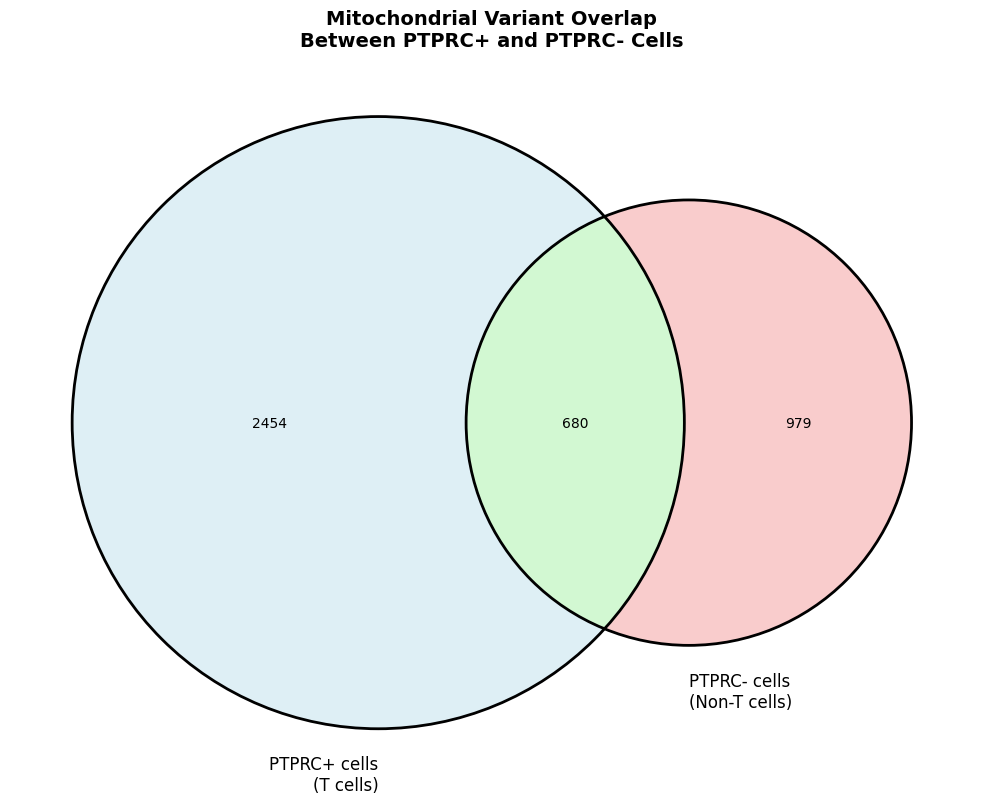

In [ ]:
# Create a Venn diagram showing variant overlap between PTPRC+ and PTPRC- cells
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import numpy as np
import pandas as pd

# Get PTPRC expression data
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    
    # Create masks for PTPRC+ and PTPRC- cells
    ptprc_positive_mask = ptprc_expression > 0
    ptprc_negative_mask = ptprc_expression == 0
    
    # Get variant data
    vaf_matrix = mgatk.obsm['variant_vaf']
    variant_names = mgatk.uns['variant_names']
    
    # Find variants present in each group
    ptprc_pos_variants = set()
    ptprc_neg_variants = set()
    
    for i, variant_name in enumerate(variant_names):
        vaf_values = vaf_matrix[:, i]
        
        # Check if variant is present in each group
        ptprc_pos_has_variant = ((vaf_values > 0) & ptprc_positive_mask).any()
        ptprc_neg_has_variant = ((vaf_values > 0) & ptprc_negative_mask).any()
        
        if ptprc_pos_has_variant:
            ptprc_pos_variants.add(variant_name)
        if ptprc_neg_has_variant:
            ptprc_neg_variants.add(variant_name)
    
    # Create Venn diagram
    plt.figure(figsize=(10, 8))
    
    # Create the Venn diagram
    venn = venn2([ptprc_pos_variants, ptprc_neg_variants], 
                 set_labels=('PTPRC+ cells\n(T cells)', 'PTPRC- cells\n(Non-T cells)'))
    
    # Customize colors
    venn.get_patch_by_id('10').set_color('lightblue')  # PTPRC+ only
    venn.get_patch_by_id('01').set_color('lightcoral')  # PTPRC- only
    venn.get_patch_by_id('11').set_color('lightgreen')  # Overlap
    
    # Add circles
    venn2_circles([ptprc_pos_variants, ptprc_neg_variants])
    
    plt.title('Mitochondrial Variant Overlap\nBetween PTPRC+ and PTPRC- Cells', fontsize=14, fontweight='bold')
    
    # Calculate overlap statistics
    overlap = ptprc_pos_variants.intersection(ptprc_neg_variants)
    ptprc_pos_only = ptprc_pos_variants - ptprc_neg_variants
    ptprc_neg_only = ptprc_neg_variants - ptprc_pos_variants
    
    print(f"Variant overlap analysis:")
    print(f"  PTPRC+ only variants: {len(ptprc_pos_only)}")
    print(f"  PTPRC- only variants: {len(ptprc_neg_only)}")
    print(f"  Shared variants: {len(overlap)}")
    print(f"  Total unique variants: {len(ptprc_pos_variants.union(ptprc_neg_variants))}")
    print(f"  Jaccard index (overlap/union): {len(overlap)/len(ptprc_pos_variants.union(ptprc_neg_variants)):.3f}")
    
    # Show some examples of shared and unique variants
    if len(overlap) > 0:
        print(f"\nExample shared variants:")
        for var in list(overlap)[:5]:
            print(f"  {var}")
    
    if len(ptprc_pos_only) > 0:
        print(f"\nExample PTPRC+ only variants:")
        for var in list(ptprc_pos_only)[:5]:
            print(f"  {var}")
    
    if len(ptprc_neg_only) > 0:
        print(f"\nExample PTPRC- only variants:")
        for var in list(ptprc_neg_only)[:5]:
            print(f"  {var}")
    
    plt.tight_layout()
    plt.show()
    
else:
    print("PTPRC not found in gene matrix")

Filtered out variants with no expression. Plotting 58 variants with expression.


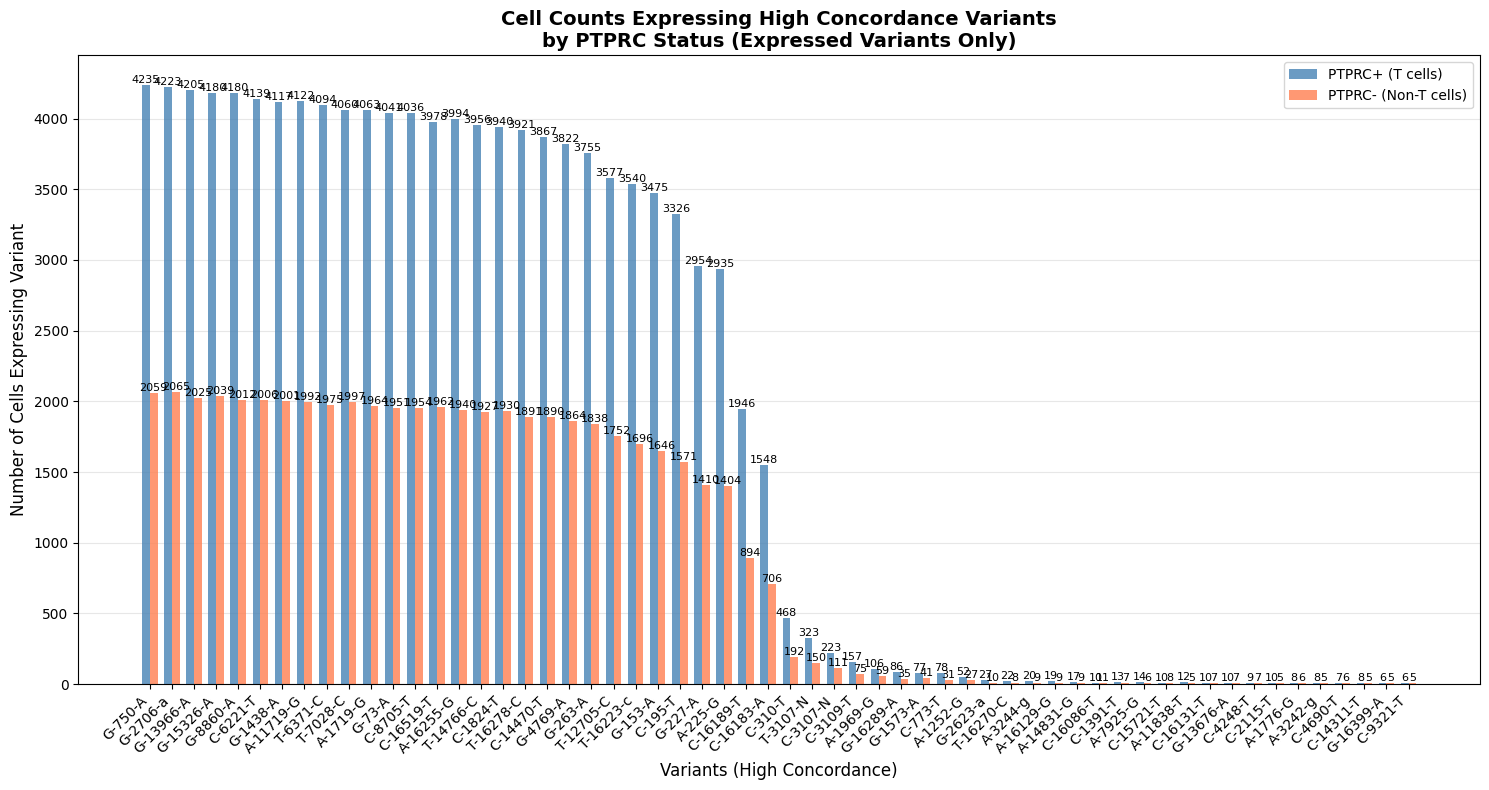


=== SUMMARY STATISTICS ===
Total high concordance variants with expression: 58
PTPRC+ cells total: 4841
PTPRC- cells total: 2785

Top 10 variants by total cell count:
      variant  PTPRC+  PTPRC-  total
50    G-750-A    4235    2059   6294
54   G-2706-a    4223    2065   6288
51  G-13966-A    4205    2025   6230
43  G-15326-A    4180    2039   6219
57   G-8860-A    4180    2012   6192
24   C-6221-T    4139    2006   6145
47   G-1438-A    4117    2001   6118
0   A-11719-G    4122    1992   6114
31   T-6371-C    4094    1975   6069
25   T-7028-C    4060    1997   6057

Total variant expressions:
  PTPRC+: 110045 (across all variants)
  PTPRC-: 53222 (across all variants)

Variants exclusive to one cell type:
  PTPRC+ only: 0 variants
  PTPRC- only: 0 variants
  Shared variants: 58 variants


In [ ]:
# Create bar chart showing cell counts expressing each high concordance variant by PTPRC status
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get PTPRC expression data
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    
    # Create masks for PTPRC+ and PTPRC- cells
    ptprc_positive_mask = ptprc_expression > 0
    ptprc_negative_mask = ptprc_expression == 0
    
    # Get variant data - ONLY high concordance variants
    vaf_matrix = mgatk.obsm['variant_vaf']
    variant_names = mgatk.uns['variant_names']
    
    # Filter to only high concordance variants
    high_concordance_variant_names = high_concordance_variants.index.tolist()
    high_concordance_indices = [i for i, name in enumerate(variant_names) if name in high_concordance_variant_names]
    
    # Collect data for plotting
    variant_data = []
    
    for i in high_concordance_indices:
        variant_name = variant_names[i]
        vaf_values = vaf_matrix[:, i]
        
        # Count cells with variants in each group
        ptprc_pos_with_variant = ((vaf_values > 0) & ptprc_positive_mask).sum()
        ptprc_neg_with_variant = ((vaf_values > 0) & ptprc_negative_mask).sum()
        
        # Only include variants that have expression in at least two cells
        if ptprc_pos_with_variant > 4 and ptprc_neg_with_variant > 4:
            variant_data.append({
                'variant': variant_name,
                'PTPRC+': ptprc_pos_with_variant,
                'PTPRC-': ptprc_neg_with_variant,
                'total': ptprc_pos_with_variant + ptprc_neg_with_variant
            })
    
    # Convert to DataFrame and sort by total cells
    variant_df = pd.DataFrame(variant_data)
    variant_df = variant_df.sort_values('total', ascending=False)
    
    print(f"Filtered out variants with no expression. Plotting {len(variant_df)} variants with expression.")
    
    # Create the bar chart
    fig, ax = plt.subplots(figsize=(15, 8))
    
    x = np.arange(len(variant_df))
    width = 0.35
    
    # Create bars
    bars1 = ax.bar(x - width/2, variant_df['PTPRC+'], width, label='PTPRC+ (T cells)', 
                   color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, variant_df['PTPRC-'], width, label='PTPRC- (Non-T cells)', 
                   color='coral', alpha=0.8)
    
    # Customize the plot
    ax.set_xlabel('Variants (High Concordance)', fontsize=12)
    ax.set_ylabel('Number of Cells Expressing Variant', fontsize=12)
    ax.set_title('Cell Counts Expressing High Concordance Variants\nby PTPRC Status (Expressed Variants Only)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(variant_df['variant'], rotation=45, ha='right', fontsize=10)
    ax.legend()
    
    # Add value labels on bars
    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                       f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    add_value_labels(bars1)
    add_value_labels(bars2)
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== SUMMARY STATISTICS ===")
    print(f"Total high concordance variants with expression: {len(variant_df)}")
    print(f"PTPRC+ cells total: {ptprc_positive_mask.sum()}")
    print(f"PTPRC- cells total: {ptprc_negative_mask.sum()}")
    
    print(f"\nTop 10 variants by total cell count:")
    print(variant_df[['variant', 'PTPRC+', 'PTPRC-', 'total']].head(10))
    
    # Calculate some interesting statistics
    ptprc_pos_total_expressing = variant_df['PTPRC+'].sum()
    ptprc_neg_total_expressing = variant_df['PTPRC-'].sum()
    
    print(f"\nTotal variant expressions:")
    print(f"  PTPRC+: {ptprc_pos_total_expressing} (across all variants)")
    print(f"  PTPRC-: {ptprc_neg_total_expressing} (across all variants)")
    
    # Variants only in one group
    ptprc_only = variant_df[variant_df['PTPRC-'] == 0]
    non_t_only = variant_df[variant_df['PTPRC+'] == 0]
    
    print(f"\nVariants exclusive to one cell type:")
    print(f"  PTPRC+ only: {len(ptprc_only)} variants")
    print(f"  PTPRC- only: {len(non_t_only)} variants")
    print(f"  Shared variants: {len(variant_df) - len(ptprc_only) - len(non_t_only)} variants")

else:
    print("PTPRC not found in gene matrix")

In [ ]:
import numpy as np
import pandas as pd

# Get the matrices
vaf_matrix = mgatk.obsm['variant_vaf'].copy()  # Make a copy to modify
coverage_matrix = mgatk.obsm['variant_coverage']
confident_matrix = mgatk.obsm['variant_confident']
variant_names = mgatk.uns['variant_names']
variant_summary = mgatk.uns['variant_summary']

print(f"Original VAF matrix shape: {vaf_matrix.shape}")
print(f"Non-zero VAF values before filtering: {(vaf_matrix > 0).sum()}")

# Count variants with at least one expressing cell before filtering
variants_with_expression_before = (vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell before filtering: {variants_with_expression_before}")

# Create high-quality filtered VAF matrix
high_quality_vaf_matrix = vaf_matrix.copy()

# For each variant, apply cell-level quality filters
for i, variant_name in enumerate(variant_names):
    # Get variant-level statistics
    variant_stats = variant_summary.iloc[i]
    strand_concordance = variant_stats['strand_concordance']
    variance = variant_stats['variance'] 
    mean_coverage = variant_stats['mean_coverage']
    
    # Get cell-level data for this variant
    cell_vaf = vaf_matrix[:, i]
    cell_coverage = coverage_matrix[:, i]
    cell_confident = confident_matrix[:, i]
    
    # Define quality criteria for this variant's cells
    quality_mask = (
        (strand_concordance >= 0.3) &  # Variant-level criterion
        (mean_coverage >= 20) &        # Variant-level criterion
        (cell_vaf >= 0.05)        # Cell-level: VAF > 5%
    )
    
    # Set non-qualifying cells to 0 for this variant
    high_quality_vaf_matrix[~quality_mask, i] = 0

print(f"Non-zero VAF values after high-quality filtering: {(high_quality_vaf_matrix > 0).sum()}")
print(f"Percentage of calls retained: {(high_quality_vaf_matrix > 0).sum() / (vaf_matrix > 0).sum() * 100:.1f}%")

# Count variants with at least one expressing cell after filtering
variants_with_expression_after = (high_quality_vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell after filtering: {variants_with_expression_after}")
print(f"Percentage of variants retained: {variants_with_expression_after / variants_with_expression_before * 100:.1f}%")

# Count variants completely eliminated by filtering
variants_eliminated = variants_with_expression_before - variants_with_expression_after
print(f"Variants completely eliminated by filtering: {variants_eliminated}")

# Store the high-quality filtered matrix
mgatk.obsm['variant_vaf_high_quality'] = high_quality_vaf_matrix

# Now you can use this filtered matrix for analysis
print("\nHigh-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']")

Original VAF matrix shape: (7626, 4710)
Non-zero VAF values before filtering: 169464
Variants with at least one expressing cell before filtering: 4113
Non-zero VAF values after high-quality filtering: 72745
Percentage of calls retained: 42.9%
Variants with at least one expressing cell after filtering: 2867
Percentage of variants retained: 69.7%
Variants completely eliminated by filtering: 1246

High-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']



ANALYZING ALL CALLS
Plotting 161 variants with >2 expressing cells using all calls.


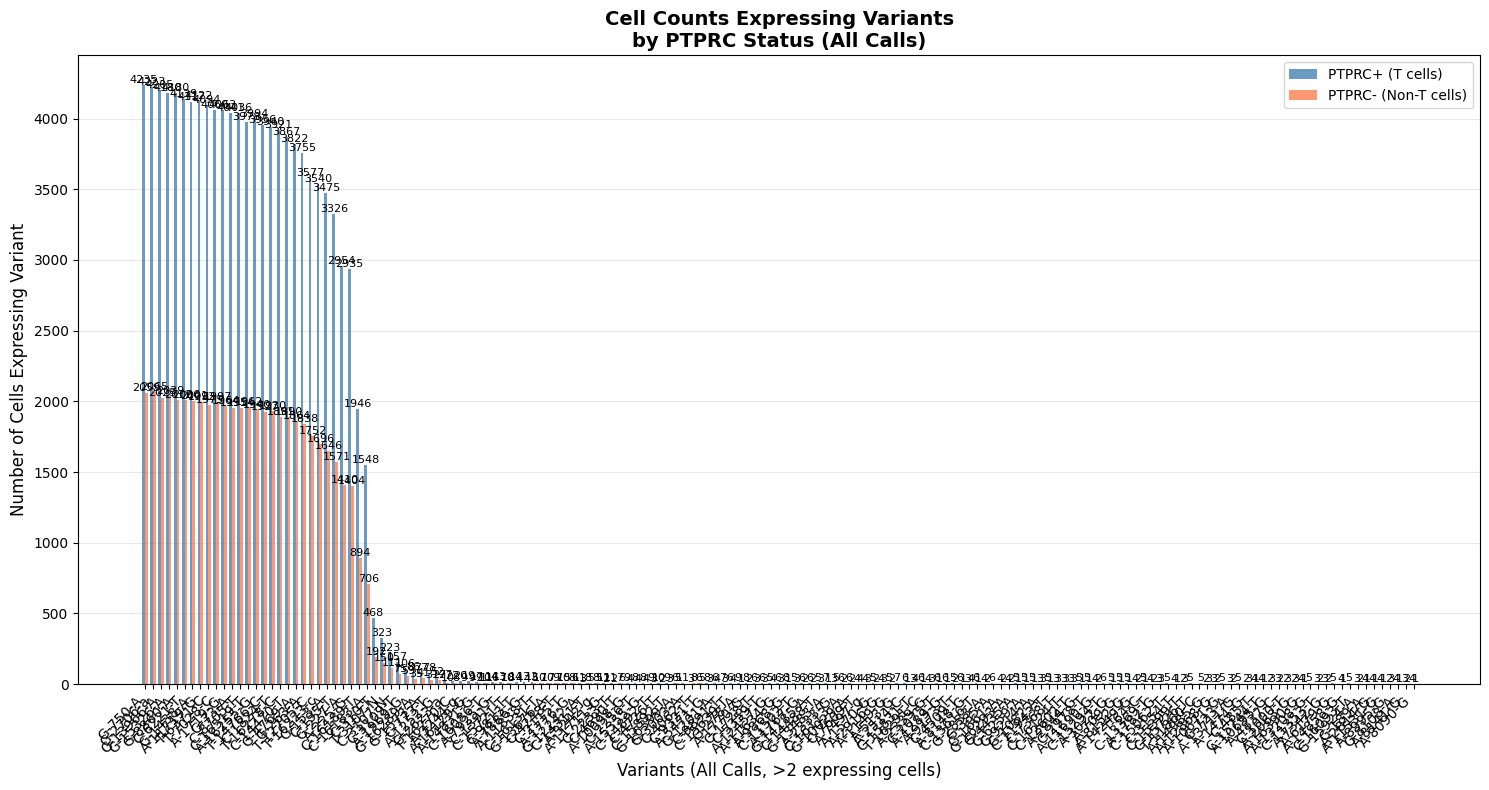


=== SUMMARY STATISTICS (ALL CALLS) ===
Total variants with >2 expressing cells: 161
PTPRC+ cells total: 4841
PTPRC- cells total: 2785

Top 10 variants by total cell count:
       variant  PTPRC+  PTPRC-  total
150    G-750-A    4235    2059   6294
155   G-2706-a    4223    2065   6288
151  G-13966-A    4205    2025   6230
133  G-15326-A    4180    2039   6219
160   G-8860-A    4180    2012   6192
61    C-6221-T    4139    2006   6145
145   G-1438-A    4117    2001   6118
0    A-11719-G    4122    1992   6114
92    T-6371-C    4094    1975   6069
63    T-7028-C    4060    1997   6057

ANALYZING HIGH QUALITY CALLS ONLY
Plotting 98 variants with >2 expressing cells using high quality calls only.


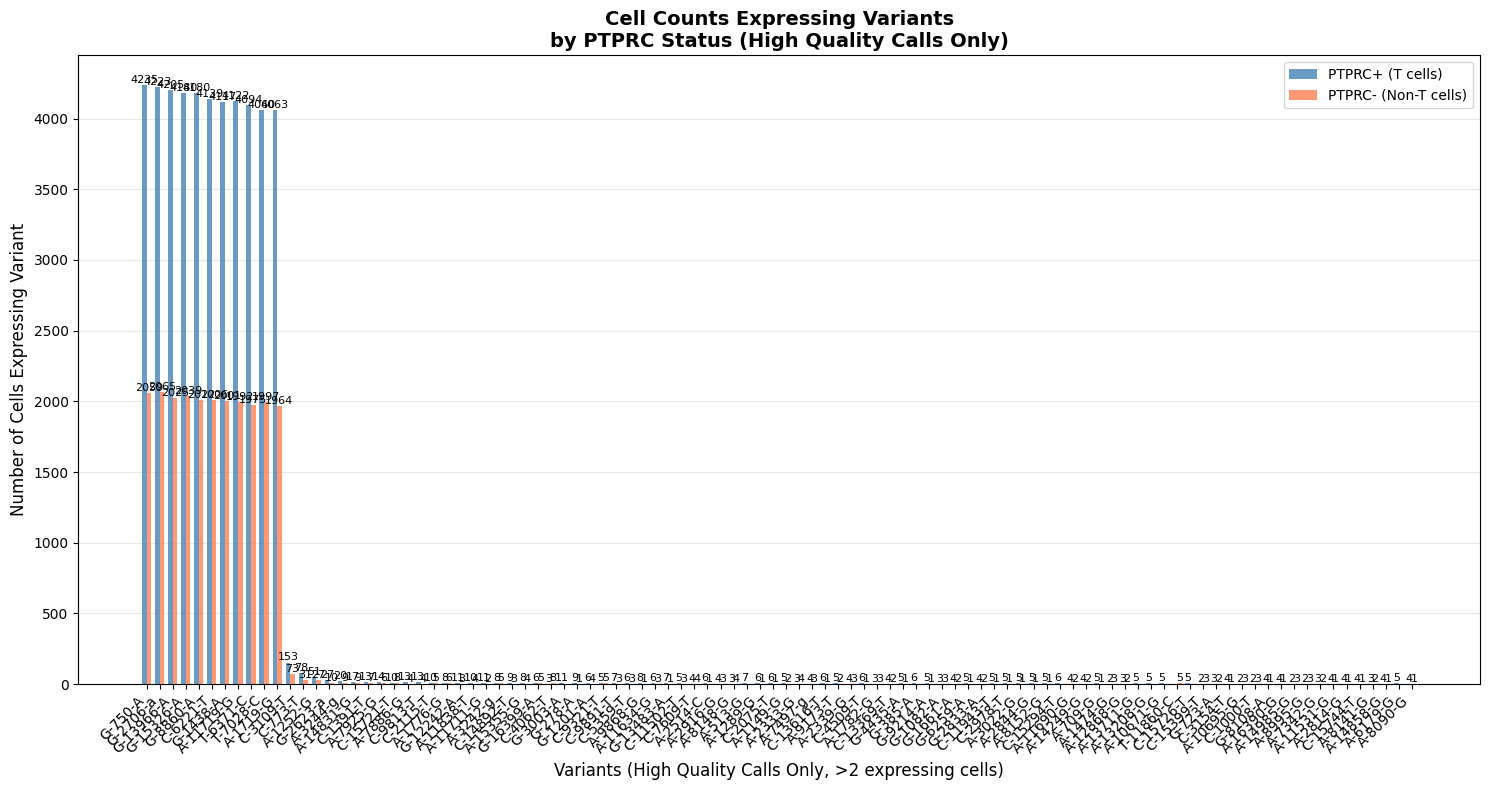


=== SUMMARY STATISTICS (HIGH QUALITY CALLS ONLY) ===
Total variants with >2 expressing cells: 98
PTPRC+ cells total: 4841
PTPRC- cells total: 2785

Top 10 variants by total cell count:
      variant  PTPRC+  PTPRC-  total
92    G-750-A    4235    2059   6294
94   G-2706-a    4223    2065   6288
93  G-13966-A    4205    2025   6230
80  G-15326-A    4180    2039   6219
97   G-8860-A    4180    2012   6192
32   C-6221-T    4139    2006   6145
88   G-1438-A    4117    2001   6118
0   A-11719-G    4122    1992   6114
58   T-6371-C    4094    1975   6069
34   T-7028-C    4060    1997   6057


In [ ]:
# Create bar chart with cell-level quality filtering
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define both approaches to compare
vaf_matrices = {
    'All Calls': mgatk.obsm['variant_vaf'],
    'High Quality Calls Only': mgatk.obsm['variant_vaf_high_quality']
}

# Get PTPRC expression data
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    
    # Create masks for PTPRC+ and PTPRC- cells
    ptprc_positive_mask = ptprc_expression > 0
    ptprc_negative_mask = ptprc_expression == 0
    
    variant_names = mgatk.uns['variant_names']
    
    # Loop through both filtering approaches
    for approach_name, vaf_matrix in vaf_matrices.items():
        print(f"\n{'='*60}")
        print(f"ANALYZING {approach_name.upper()}")
        print(f"{'='*60}")
        
        # Collect data for plotting - use ALL variants but with filtered calls
        variant_data = []
        
        for i, variant_name in enumerate(variant_names):
            vaf_values = vaf_matrix[:, i]
            
            # Count cells with variants in each group
            ptprc_pos_with_variant = ((vaf_values > 0) & ptprc_positive_mask).sum()
            ptprc_neg_with_variant = ((vaf_values > 0) & ptprc_negative_mask).sum()
            total_expressing = ptprc_pos_with_variant + ptprc_neg_with_variant

            # Only include variants with more than 4 total expressing cells
            if total_expressing > 4:
                variant_data.append({
                    'variant': variant_name,
                    'PTPRC+': ptprc_pos_with_variant,
                    'PTPRC-': ptprc_neg_with_variant,
                    'total': total_expressing
                })
        
        # Convert to DataFrame and sort by total cells
        variant_df = pd.DataFrame(variant_data)
        
        if len(variant_df) == 0:
            print(f"No variants found with >2 expressing cells using {approach_name.lower()}. Skipping plot.")
            continue
            
        variant_df = variant_df.sort_values('total', ascending=False)
        
        print(f"Plotting {len(variant_df)} variants with >2 expressing cells using {approach_name.lower()}.")
        
        # Create the bar chart
        fig, ax = plt.subplots(figsize=(15, 8))
        
        x = np.arange(len(variant_df))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, variant_df['PTPRC+'], width, label='PTPRC+ (T cells)', 
                       color='steelblue', alpha=0.8)
        bars2 = ax.bar(x + width/2, variant_df['PTPRC-'], width, label='PTPRC- (Non-T cells)', 
                       color='coral', alpha=0.8)
        
        # Customize the plot
        ax.set_xlabel(f'Variants ({approach_name}, >2 expressing cells)', fontsize=12)
        ax.set_ylabel('Number of Cells Expressing Variant', fontsize=12)
        ax.set_title(f'Cell Counts Expressing Variants\nby PTPRC Status ({approach_name})', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(variant_df['variant'], rotation=45, ha='right', fontsize=10)
        ax.legend()
        
        # Add value labels on bars
        def add_value_labels(bars):
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                           f'{int(height)}', ha='center', va='bottom', fontsize=8)
        
        add_value_labels(bars1)
        add_value_labels(bars2)
        
        # Add grid for better readability
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\n=== SUMMARY STATISTICS ({approach_name.upper()}) ===")
        print(f"Total variants with >2 expressing cells: {len(variant_df)}")
        print(f"PTPRC+ cells total: {ptprc_positive_mask.sum()}")
        print(f"PTPRC- cells total: {ptprc_negative_mask.sum()}")
        
        print(f"\nTop 10 variants by total cell count:")
        print(variant_df[['variant', 'PTPRC+', 'PTPRC-', 'total']].head(10))

else:
    print("PTPRC not found in gene matrix")


ALL CALLS - Variant overlap analysis:
  PTPRC+ only variants: 2454
  PTPRC- only variants: 979
  Shared variants: 680
  Total unique variants: 4113
  Jaccard index (overlap/union): 0.165

Example shared variants (All Calls):
  C-2952-T
  A-2814-G
  A-11719-G
  C-2966-T
  G-1171-A

Example PTPRC+ only variants (All Calls):
  A-6249-G
  C-2407-T
  C-11046-T
  C-4023-T
  A-14960-G

Example PTPRC- only variants (All Calls):
  T-5317-C
  C-2648-t
  C-16044-T
  G-11293-A
  A-6630-G

HIGH QUALITY CALLS - Variant overlap analysis:
  PTPRC+ only variants: 1710
  PTPRC- only variants: 672
  Shared variants: 485
  Total unique variants: 2867
  Jaccard index (overlap/union): 0.169

Example shared variants (High Quality Calls):
  A-2814-G
  C-2952-T
  A-11719-G
  G-1171-A
  C-2966-T

Example PTPRC+ only variants (High Quality Calls):
  A-6249-G
  A-14960-G
  T-4827-C
  C-8159-T
  G-5620-A

Example PTPRC- only variants (High Quality Calls):
  T-5317-C
  C-2648-t
  C-971-A
  G-11293-A
  A-6630-G


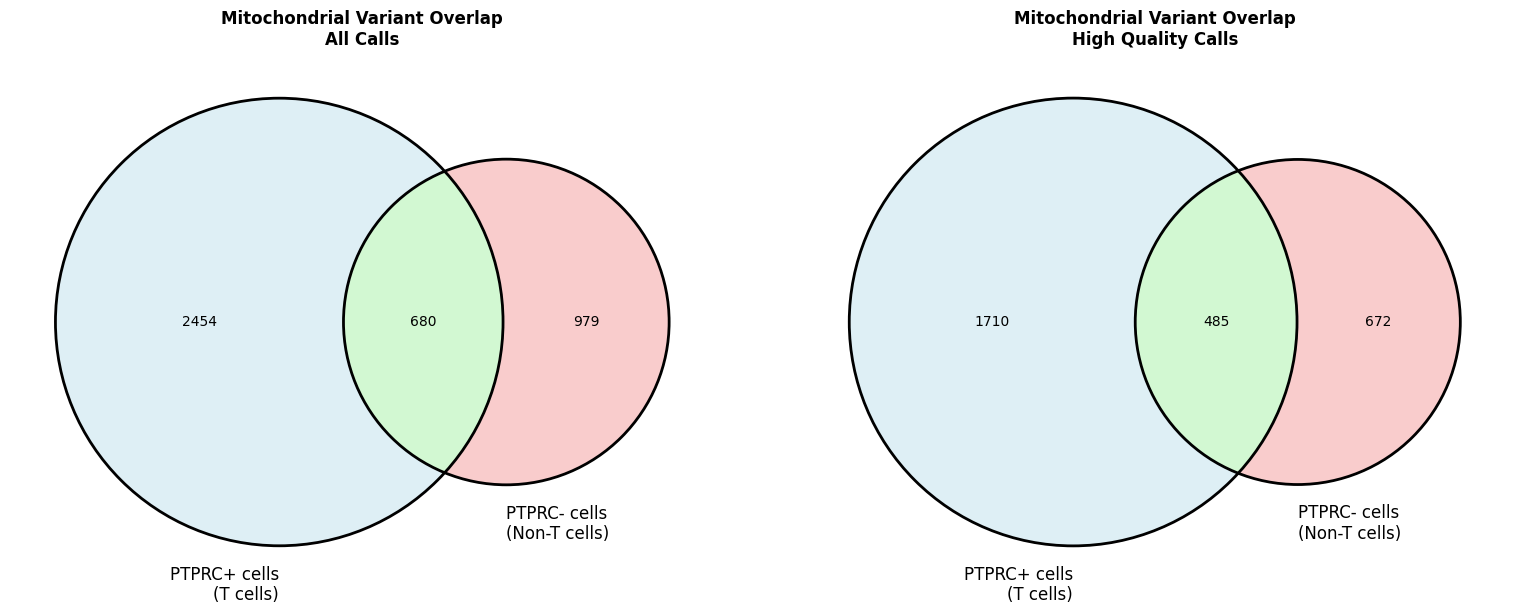


COMPARISON BETWEEN ALL CALLS vs HIGH QUALITY CALLS


In [ ]:
# Create Venn diagrams showing variant overlap between PTPRC+ and PTPRC- cells
# Compare both all calls and high-quality calls
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import numpy as np
import pandas as pd

# Get PTPRC expression data
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    
    # Create masks for PTPRC+ and PTPRC- cells
    ptprc_positive_mask = ptprc_expression > 0
    ptprc_negative_mask = ptprc_expression == 0
    
    # Get variant data - both filtered and unfiltered
    vaf_matrices = {
        'All Calls': mgatk.obsm['variant_vaf'],
        'High Quality Calls': mgatk.obsm['variant_vaf_high_quality']
    }
    variant_names = mgatk.uns['variant_names']
    
    # Create side-by-side Venn diagrams
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, (approach_name, vaf_matrix) in enumerate(vaf_matrices.items()):
        ax = ax1 if idx == 0 else ax2
        
        # Find variants present in each group
        ptprc_pos_variants = set()
        ptprc_neg_variants = set()
        
        for i, variant_name in enumerate(variant_names):
            vaf_values = vaf_matrix[:, i]
            
            # Check if variant is present in each group
            ptprc_pos_has_variant = ((vaf_values > 0) & ptprc_positive_mask).any()
            ptprc_neg_has_variant = ((vaf_values > 0) & ptprc_negative_mask).any()
            
            if ptprc_pos_has_variant:
                ptprc_pos_variants.add(variant_name)
            if ptprc_neg_has_variant:
                ptprc_neg_variants.add(variant_name)
        
        # Create the Venn diagram
        venn = venn2([ptprc_pos_variants, ptprc_neg_variants], 
                     set_labels=('PTPRC+ cells\n(T cells)', 'PTPRC- cells\n(Non-T cells)'),
                     ax=ax)
        
        # Customize colors
        if venn.get_patch_by_id('10'):
            venn.get_patch_by_id('10').set_color('lightblue')  # PTPRC+ only
        if venn.get_patch_by_id('01'):
            venn.get_patch_by_id('01').set_color('lightcoral')  # PTPRC- only
        if venn.get_patch_by_id('11'):
            venn.get_patch_by_id('11').set_color('lightgreen')  # Overlap
        
        # Add circles
        venn2_circles([ptprc_pos_variants, ptprc_neg_variants], ax=ax)
        
        ax.set_title(f'Mitochondrial Variant Overlap\n{approach_name}', 
                     fontsize=12, fontweight='bold')
        
        # Calculate overlap statistics
        overlap = ptprc_pos_variants.intersection(ptprc_neg_variants)
        ptprc_pos_only = ptprc_pos_variants - ptprc_neg_variants
        ptprc_neg_only = ptprc_neg_variants - ptprc_pos_variants
        total_unique = len(ptprc_pos_variants.union(ptprc_neg_variants))
        
        print(f"\n{approach_name.upper()} - Variant overlap analysis:")
        print(f"  PTPRC+ only variants: {len(ptprc_pos_only)}")
        print(f"  PTPRC- only variants: {len(ptprc_neg_only)}")
        print(f"  Shared variants: {len(overlap)}")
        print(f"  Total unique variants: {total_unique}")
        if total_unique > 0:
            print(f"  Jaccard index (overlap/union): {len(overlap)/total_unique:.3f}")
        
        # Show some examples of shared and unique variants
        if len(overlap) > 0:
            print(f"\nExample shared variants ({approach_name}):")
            for var in list(overlap)[:5]:
                print(f"  {var}")
        
        if len(ptprc_pos_only) > 0:
            print(f"\nExample PTPRC+ only variants ({approach_name}):")
            for var in list(ptprc_pos_only)[:5]:
                print(f"  {var}")
        
        if len(ptprc_neg_only) > 0:
            print(f"\nExample PTPRC- only variants ({approach_name}):")
            for var in list(ptprc_neg_only)[:5]:
                print(f"  {var}")
    
    plt.tight_layout()
    plt.show()
    
    # Summary comparison between approaches
    print(f"\n{'='*60}")
    print("COMPARISON BETWEEN ALL CALLS vs HIGH QUALITY CALLS")
    print(f"{'='*60}")
    
else:
    print("PTPRC not found in gene matrix")

In [ ]:
# Split cells by PTPRC expression and analyze HIGH QUALITY mitochondrial variants
import numpy as np
import pandas as pd

# Get PTPRC expression data
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    
    # Create masks for PTPRC+ and PTPRC- cells
    ptprc_positive_mask = ptprc_expression > 0
    ptprc_negative_mask = ptprc_expression == 0
    
    print(f"PTPRC+ cells: {ptprc_positive_mask.sum()}")
    print(f"PTPRC- cells: {ptprc_negative_mask.sum()}")
    print(f"Total cells: {len(ptprc_expression)}")
    
    # Get HIGH QUALITY variant data
    vaf_matrix = mgatk.obsm['variant_vaf_high_quality']  # Using high quality filtered matrix
    variant_names = mgatk.uns['variant_names']
    
    # Calculate variants per individual cell for HIGH QUALITY variants
    print(f"\n=== CALCULATING HIGH QUALITY VARIANTS PER INDIVIDUAL CELL ===")
    
    # For PTPRC+ cells
    ptprc_pos_cells_variants = []
    for cell_idx in np.where(ptprc_positive_mask)[0]:
        cell_vaf_values = vaf_matrix[cell_idx, :]
        variants_in_cell = (cell_vaf_values > 0).sum()
        ptprc_pos_cells_variants.append(variants_in_cell)
    
    # For PTPRC- cells
    ptprc_neg_cells_variants = []
    for cell_idx in np.where(ptprc_negative_mask)[0]:
        cell_vaf_values = vaf_matrix[cell_idx, :]
        variants_in_cell = (cell_vaf_values > 0).sum()
        ptprc_neg_cells_variants.append(variants_in_cell)
    
    # Convert to numpy arrays for easier calculation
    ptprc_pos_variants_per_cell = np.array(ptprc_pos_cells_variants)
    ptprc_neg_variants_per_cell = np.array(ptprc_neg_cells_variants)
    
    # Analyze variants in each group (variant-level analysis for high quality)
    ptprc_pos_variants = []
    ptprc_neg_variants = []
    
    for i, variant_name in enumerate(variant_names):
        vaf_values = vaf_matrix[:, i]
        
        # Count cells with variants in each group
        ptprc_pos_with_variant = ((vaf_values > 0) & ptprc_positive_mask).sum()
        ptprc_neg_with_variant = ((vaf_values > 0) & ptprc_negative_mask).sum()
        
        if ptprc_pos_with_variant > 0:
            ptprc_pos_variants.append({
                'variant': variant_name,
                'cells_with_variant': ptprc_pos_with_variant,
                'total_cells': ptprc_positive_mask.sum(),
                'percentage': ptprc_pos_with_variant / ptprc_positive_mask.sum() * 100
            })
            
        if ptprc_neg_with_variant > 0:
            ptprc_neg_variants.append({
                'variant': variant_name,
                'cells_with_variant': ptprc_neg_with_variant,
                'total_cells': ptprc_negative_mask.sum(),
                'percentage': ptprc_neg_with_variant / ptprc_negative_mask.sum() * 100
            })
    
    # Convert to DataFrames for easy viewing
    ptprc_pos_df = pd.DataFrame(ptprc_pos_variants)
    ptprc_neg_df = pd.DataFrame(ptprc_neg_variants)
    
    print(f"\n=== PTPRC+ cells (T cells) - HIGH QUALITY VARIANTS ===")
    print(f"Number of high quality variants detected: {len(ptprc_pos_df)}")
    if len(ptprc_pos_df) > 0:
        print("Top 10 most frequent high quality variants:")
        print(ptprc_pos_df.sort_values('cells_with_variant', ascending=False).head(10))
    
    print(f"\n=== PTPRC- cells (Non-T cells) - HIGH QUALITY VARIANTS ===")
    print(f"Number of high quality variants detected: {len(ptprc_neg_df)}")
    if len(ptprc_neg_df) > 0:
        print("Top 10 most frequent high quality variants:")
        print(ptprc_neg_df.sort_values('cells_with_variant', ascending=False).head(10))
    
    # Enhanced summary with per-cell variant statistics for HIGH QUALITY variants
    print(f"\n=== ENHANCED SUMMARY - HIGH QUALITY VARIANTS ===")
    print(f"PTPRC+ cells: {ptprc_positive_mask.sum()} cells, {len(ptprc_pos_df)} unique high quality variants detected")
    print(f"PTPRC- cells: {ptprc_negative_mask.sum()} cells, {len(ptprc_neg_df)} unique high quality variants detected")
    
    # Original variants per cell ratio (unique variants / total cells)
    print(f"\nUnique high quality variants per cell ratio:")
    print(f"  PTPRC+: {len(ptprc_pos_df) / ptprc_positive_mask.sum():.3f} unique variants/cell")
    print(f"  PTPRC-: {len(ptprc_neg_df) / ptprc_negative_mask.sum():.3f} unique variants/cell")
    
    # NEW: Actual high quality variants per individual cell statistics
    print(f"\nHigh quality variants per individual cell statistics:")
    print(f"  PTPRC+ cells:")
    print(f"    Mean variants per cell: {ptprc_pos_variants_per_cell.mean():.2f}")
    print(f"    Median variants per cell: {np.median(ptprc_pos_variants_per_cell):.2f}")
    print(f"    Min variants per cell: {ptprc_pos_variants_per_cell.min()}")
    print(f"    Max variants per cell: {ptprc_pos_variants_per_cell.max()}")
    print(f"    Std variants per cell: {ptprc_pos_variants_per_cell.std():.2f}")
    
    print(f"  PTPRC- cells:")
    print(f"    Mean variants per cell: {ptprc_neg_variants_per_cell.mean():.2f}")
    print(f"    Median variants per cell: {np.median(ptprc_neg_variants_per_cell):.2f}")
    print(f"    Min variants per cell: {ptprc_neg_variants_per_cell.min()}")
    print(f"    Max variants per cell: {ptprc_neg_variants_per_cell.max()}")
    print(f"    Std variants per cell: {ptprc_neg_variants_per_cell.std():.2f}")
    
    # Distribution of high quality variants per cell
    print(f"\nDistribution of high quality variants per cell:")
    print(f"  PTPRC+ cells with 0 variants: {(ptprc_pos_variants_per_cell == 0).sum()} ({(ptprc_pos_variants_per_cell == 0).sum()/len(ptprc_pos_variants_per_cell)*100:.1f}%)")
    print(f"  PTPRC+ cells with 1-5 variants: {((ptprc_pos_variants_per_cell >= 1) & (ptprc_pos_variants_per_cell <= 5)).sum()} ({((ptprc_pos_variants_per_cell >= 1) & (ptprc_pos_variants_per_cell <= 5)).sum()/len(ptprc_pos_variants_per_cell)*100:.1f}%)")
    print(f"  PTPRC+ cells with >5 variants: {(ptprc_pos_variants_per_cell > 5).sum()} ({(ptprc_pos_variants_per_cell > 5).sum()/len(ptprc_pos_variants_per_cell)*100:.1f}%)")
    
    print(f"  PTPRC- cells with 0 variants: {(ptprc_neg_variants_per_cell == 0).sum()} ({(ptprc_neg_variants_per_cell == 0).sum()/len(ptprc_neg_variants_per_cell)*100:.1f}%)")
    print(f"  PTPRC- cells with 1-5 variants: {((ptprc_neg_variants_per_cell >= 1) & (ptprc_neg_variants_per_cell <= 5)).sum()} ({((ptprc_neg_variants_per_cell >= 1) & (ptprc_neg_variants_per_cell <= 5)).sum()/len(ptprc_neg_variants_per_cell)*100:.1f}%)")
    print(f"  PTPRC- cells with >5 variants: {(ptprc_neg_variants_per_cell > 5).sum()} ({(ptprc_neg_variants_per_cell > 5).sum()/len(ptprc_neg_variants_per_cell)*100:.1f}%)")
    
    # Total high quality variant expressions across all cells
    total_ptprc_pos_expressions = ptprc_pos_variants_per_cell.sum()
    total_ptprc_neg_expressions = ptprc_neg_variants_per_cell.sum()
    
    print(f"\nTotal high quality variant expressions:")
    print(f"  PTPRC+: {total_ptprc_pos_expressions} total variant expressions across {ptprc_positive_mask.sum()} cells")
    print(f"  PTPRC-: {total_ptprc_neg_expressions} total variant expressions across {ptprc_negative_mask.sum()} cells")
    print(f"  Average high quality expressions per cell:")
    print(f"    PTPRC+: {total_ptprc_pos_expressions / ptprc_positive_mask.sum():.2f}")
    print(f"    PTPRC-: {total_ptprc_neg_expressions / ptprc_negative_mask.sum():.2f}")
    # ...existing code...
    
    # Total high quality variant expressions across all cells
    total_ptprc_pos_expressions = ptprc_pos_variants_per_cell.sum()
    total_ptprc_neg_expressions = ptprc_neg_variants_per_cell.sum()
    
    print(f"\nTotal high quality variant expressions:")
    print(f"  PTPRC+: {total_ptprc_pos_expressions} total variant expressions across {ptprc_positive_mask.sum()} cells")
    print(f"  PTPRC-: {total_ptprc_neg_expressions} total variant expressions across {ptprc_negative_mask.sum()} cells")
    print(f"  Average high quality expressions per cell:")
    print(f"    PTPRC+: {total_ptprc_pos_expressions / ptprc_positive_mask.sum():.2f}")
    print(f"    PTPRC-: {total_ptprc_neg_expressions / ptprc_negative_mask.sum():.2f}")
    
    # Statistical significance testing
    from scipy import stats
    
    print(f"\n=== STATISTICAL SIGNIFICANCE TESTING ===")
    
    # Mann-Whitney U test (non-parametric, doesn't assume normal distribution)
    statistic, p_value_mw = stats.mannwhitneyu(
        ptprc_pos_variants_per_cell, 
        ptprc_neg_variants_per_cell, 
        alternative='two-sided'
    )
    
    # Welch's t-test (assumes unequal variances)
    statistic_t, p_value_t = stats.ttest_ind(
        ptprc_pos_variants_per_cell, 
        ptprc_neg_variants_per_cell, 
        equal_var=False
    )
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(ptprc_pos_variants_per_cell) - 1) * ptprc_pos_variants_per_cell.var() + 
                         (len(ptprc_neg_variants_per_cell) - 1) * ptprc_neg_variants_per_cell.var()) / 
                        (len(ptprc_pos_variants_per_cell) + len(ptprc_neg_variants_per_cell) - 2))
    
    cohens_d = (ptprc_pos_variants_per_cell.mean() - ptprc_neg_variants_per_cell.mean()) / pooled_std
    
    print(f"Mann-Whitney U test:")
    print(f"  U-statistic: {statistic}")
    print(f"  p-value: {p_value_mw:.2e}")
    print(f"  Significant at α=0.05: {'Yes' if p_value_mw < 0.05 else 'No'}")
    print(f"  Significant at α=0.001: {'Yes' if p_value_mw < 0.001 else 'No'}")
    
    print(f"\nWelch's t-test:")
    print(f"  t-statistic: {statistic_t:.3f}")
    print(f"  p-value: {p_value_t:.2e}")
    print(f"  Significant at α=0.05: {'Yes' if p_value_t < 0.05 else 'No'}")
    print(f"  Significant at α=0.001: {'Yes' if p_value_t < 0.001 else 'No'}")
    
    print(f"\nEffect size:")
    print(f"  Cohen's d: {cohens_d:.3f}")
    if abs(cohens_d) < 0.2:
        effect_size = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_size = "small"
    elif abs(cohens_d) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"
    print(f"  Effect size interpretation: {effect_size}")
    
    # Descriptive statistics for context
    print(f"\nDescriptive statistics:")
    print(f"  PTPRC+ mean ± std: {ptprc_pos_variants_per_cell.mean():.2f} ± {ptprc_pos_variants_per_cell.std():.2f}")
    print(f"  PTPRC- mean ± std: {ptprc_neg_variants_per_cell.mean():.2f} ± {ptprc_neg_variants_per_cell.std():.2f}")
    print(f"  Difference in means: {ptprc_pos_variants_per_cell.mean() - ptprc_neg_variants_per_cell.mean():.2f}")
    
    # Confidence interval for the difference in means
    from scipy.stats import bootstrap
    
    def mean_diff(x, y):
        return np.mean(x) - np.mean(y)
    
    # Bootstrap confidence interval
    rng = np.random.default_rng(42)  # for reproducibility
    res = bootstrap((ptprc_pos_variants_per_cell, ptprc_neg_variants_per_cell), 
                    mean_diff, n_resamples=10000, 
                    random_state=rng, paired=False)
    
    print(f"\n95% Confidence interval for difference in means:")
    print(f"  [{res.confidence_interval.low:.2f}, {res.confidence_interval.high:.2f}]")
    print(f"  Interpretation: We are 95% confident the true difference lies within this range")
    if res.confidence_interval.low > 0:
        print(f"  Since the entire CI is above 0, PTPRC+ cells have significantly more variants")
    elif res.confidence_interval.high < 0:
        print(f"  Since the entire CI is below 0, PTPRC- cells have significantly more variants")
    else:
        print(f"  Since the CI includes 0, the difference may not be significant")
    
else:
    print("PTPRC not found in gene matrix")
    


PTPRC+ cells: 4841
PTPRC- cells: 2785
Total cells: 7626

=== CALCULATING HIGH QUALITY VARIANTS PER INDIVIDUAL CELL ===

=== PTPRC+ cells (T cells) - HIGH QUALITY VARIANTS ===
Number of high quality variants detected: 2195
Top 10 most frequent high quality variants:
        variant  cells_with_variant  total_cells  percentage
2133    G-750-A                4235         4841   87.481925
2176   G-2706-a                4223         4841   87.234043
2169  G-13966-A                4205         4841   86.862219
1889  G-15326-A                4180         4841   86.345796
2193   G-8860-A                4180         4841   86.345796
662    C-6221-T                4139         4841   85.498864
2     A-11719-G                4122         4841   85.147697
2090   G-1438-A                4117         4841   85.044412
1192   T-6371-C                4094         4841   84.569304
13     A-1719-G                4063         4841   83.928940

=== PTPRC- cells (Non-T cells) - HIGH QUALITY VARIANTS ===
Num

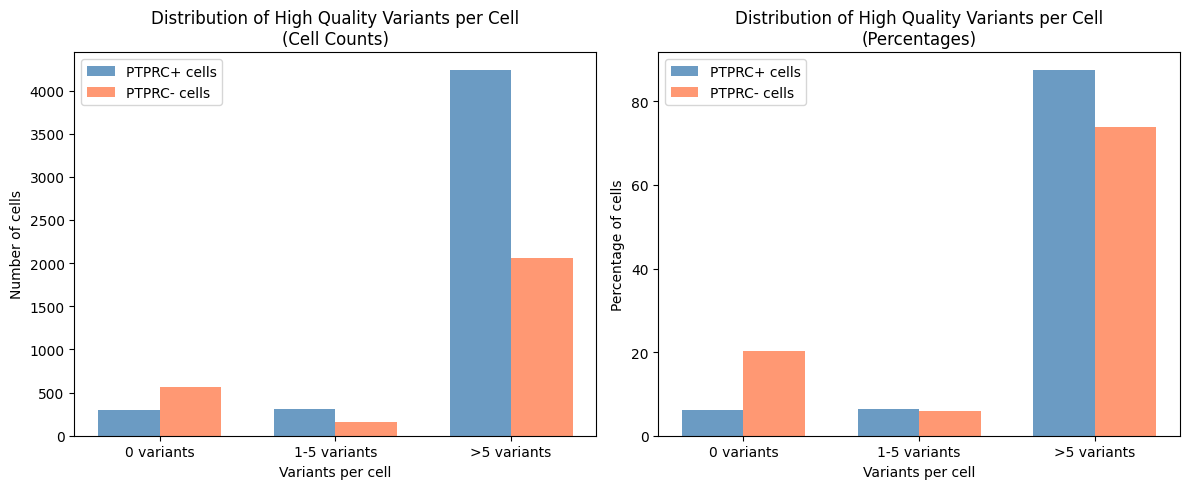

In [ ]:
# Plot distribution of high quality variants per cell
import matplotlib.pyplot as plt
import numpy as np

# Data from the distribution output
categories = ['0 variants', '1-5 variants', '>5 variants']
ptprc_pos_counts = [294, 314, 4233]
ptprc_neg_counts = [565, 164, 2056]
ptprc_pos_pcts = [6.1, 6.5, 87.4]
ptprc_neg_pcts = [20.3, 5.9, 73.8]

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Cell counts
x = np.arange(len(categories))
width = 0.35

ax1.bar(x - width/2, ptprc_pos_counts, width, label='PTPRC+ cells', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, ptprc_neg_counts, width, label='PTPRC- cells', color='coral', alpha=0.8)
ax1.set_xlabel('Variants per cell')
ax1.set_ylabel('Number of cells')
ax1.set_title('Distribution of High Quality Variants per Cell\n(Cell Counts)')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()

# Plot 2: Percentages
ax2.bar(x - width/2, ptprc_pos_pcts, width, label='PTPRC+ cells', color='steelblue', alpha=0.8)
ax2.bar(x + width/2, ptprc_neg_pcts, width, label='PTPRC- cells', color='coral', alpha=0.8)
ax2.set_xlabel('Variants per cell')
ax2.set_ylabel('Percentage of cells')
ax2.set_title('Distribution of High Quality Variants per Cell\n(Percentages)')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
##Export high quality variants to CSV
# Get high quality variants from the filtered matrix
vaf_matrix = mgatk.obsm['variant_vaf_high_quality']
variant_names = mgatk.uns['variant_names']

# Find variants that have at least one cell with expression
variants_with_expression = []

for i, variant_name in enumerate(variant_names):
    if (vaf_matrix[:, i] > 0).any():  # Check if any cell has this variant
        # Parse variant name (format: "alt-pos-ref")
        parts = variant_name.split('-')
        if len(parts) == 3:
            alt, pos, ref = parts
            variants_with_expression.append({
                'chr': 'MT',
                'sample': 'PBMC_PostMortem',
                'pos': int(pos),
                'ref': ref.upper(),
                'alt': alt.upper()
            })

# Create DataFrame and save to CSV
variants_df = pd.DataFrame(variants_with_expression)
variants_df = variants_df.sort_values('pos')  # Sort by position

# Save to CSV
variants_df.to_csv('PBMC_PostMortem_variants.csv', index=False)

print(f"Exported {len(variants_df)} high quality variants to PBMC_PostMortem_variants.csv")
print("\nFirst 10 variants:")
print(variants_df.head(10))

Exported 2867 high quality variants to PBMC_PostMortem_variants.csv

First 10 variants:
     chr           sample  pos ref alt
1961  MT  PBMC_PostMortem   81   G   A
1121  MT  PBMC_PostMortem  277   C   G
2222  MT  PBMC_PostMortem  278   A   G
2032  MT  PBMC_PostMortem  279   T   C
2068  MT  PBMC_PostMortem  279   T   G
2487  MT  PBMC_PostMortem  283   A   G
596   MT  PBMC_PostMortem  369   C   T
2637  MT  PBMC_PostMortem  373   A   G
2638  MT  PBMC_PostMortem  374   A   G
2498  MT  PBMC_PostMortem  385   A   G


In [ ]:
import genebe as gnb
annotated_PBMC = gnb.annotate_dataframe_variants(variants_df,use_ensembl=True,use_refseq=False, genome='hg38', flatten_consequences=False)

2025-11-11 16:03:33 - WARNING - You are not logged in to GeneBe. We recommend using username and api_key arguments. Find out more on https://genebe.net/api .


Error: .netrc file not found.


  0%|          | 0/29 [00:00<?, ?it/s]


TooManyRequestsError: Too many requests (429 error). Please provide a username and API key. More information at https://genebe.net/api

In [ ]:
annotated_PBMC.to_csv('PBMC_PostMortem_genebe.csv', index=False)

In [ ]:
#Gene classification 
gene_classification = {
    'MT-ND1': 'Complex I',
    'MT-ND2': 'Complex I',
    'MT-ND3': 'Complex I',
    'MT-ND4': 'Complex I',
    'MT-ND4L': 'Complex I',
    'MT-ND5': 'Complex I',
    'MT-ND6': 'Complex I',
    'MT-CO1': 'Complex IV',
    'MT-CO2': 'Complex IV',
    'MT-CO3': 'Complex IV',
    'MT-CYB': 'Complex III',
    'MT-ATP6': 'Complex V',
    'MT-ATP8': 'Complex V',
    'MT-RNR1': 'rRNA',
    'MT-RNR2': 'rRNA',
    'MT-TF': 'tRNA',  
    'MT-TV': 'tRNA',
    'MT-TI': 'tRNA',
    'MT-TL1': 'tRNA',
    'MT-TL2': 'tRNA',
    'MT-TK': 'tRNA',
    'MT-TM': 'tRNA',
    'MT-TP': 'tRNA',
    'MT-TS1': 'tRNA',
    'MT-TS2': 'tRNA',
    'MT-TW': 'tRNA',
    'MT-TA': 'tRNA',
    'MT-TC': 'tRNA',
    'MT-TY': 'tRNA',
    'MT-TH': 'tRNA',
    'MT-TG': 'tRNA',
    'MT-TR': 'tRNA',
    'MT-TN': 'tRNA',
    'MT-TD': 'tRNA',
    'MT-TE': 'tRNA',
    'MT-TQ': 'tRNA'
}

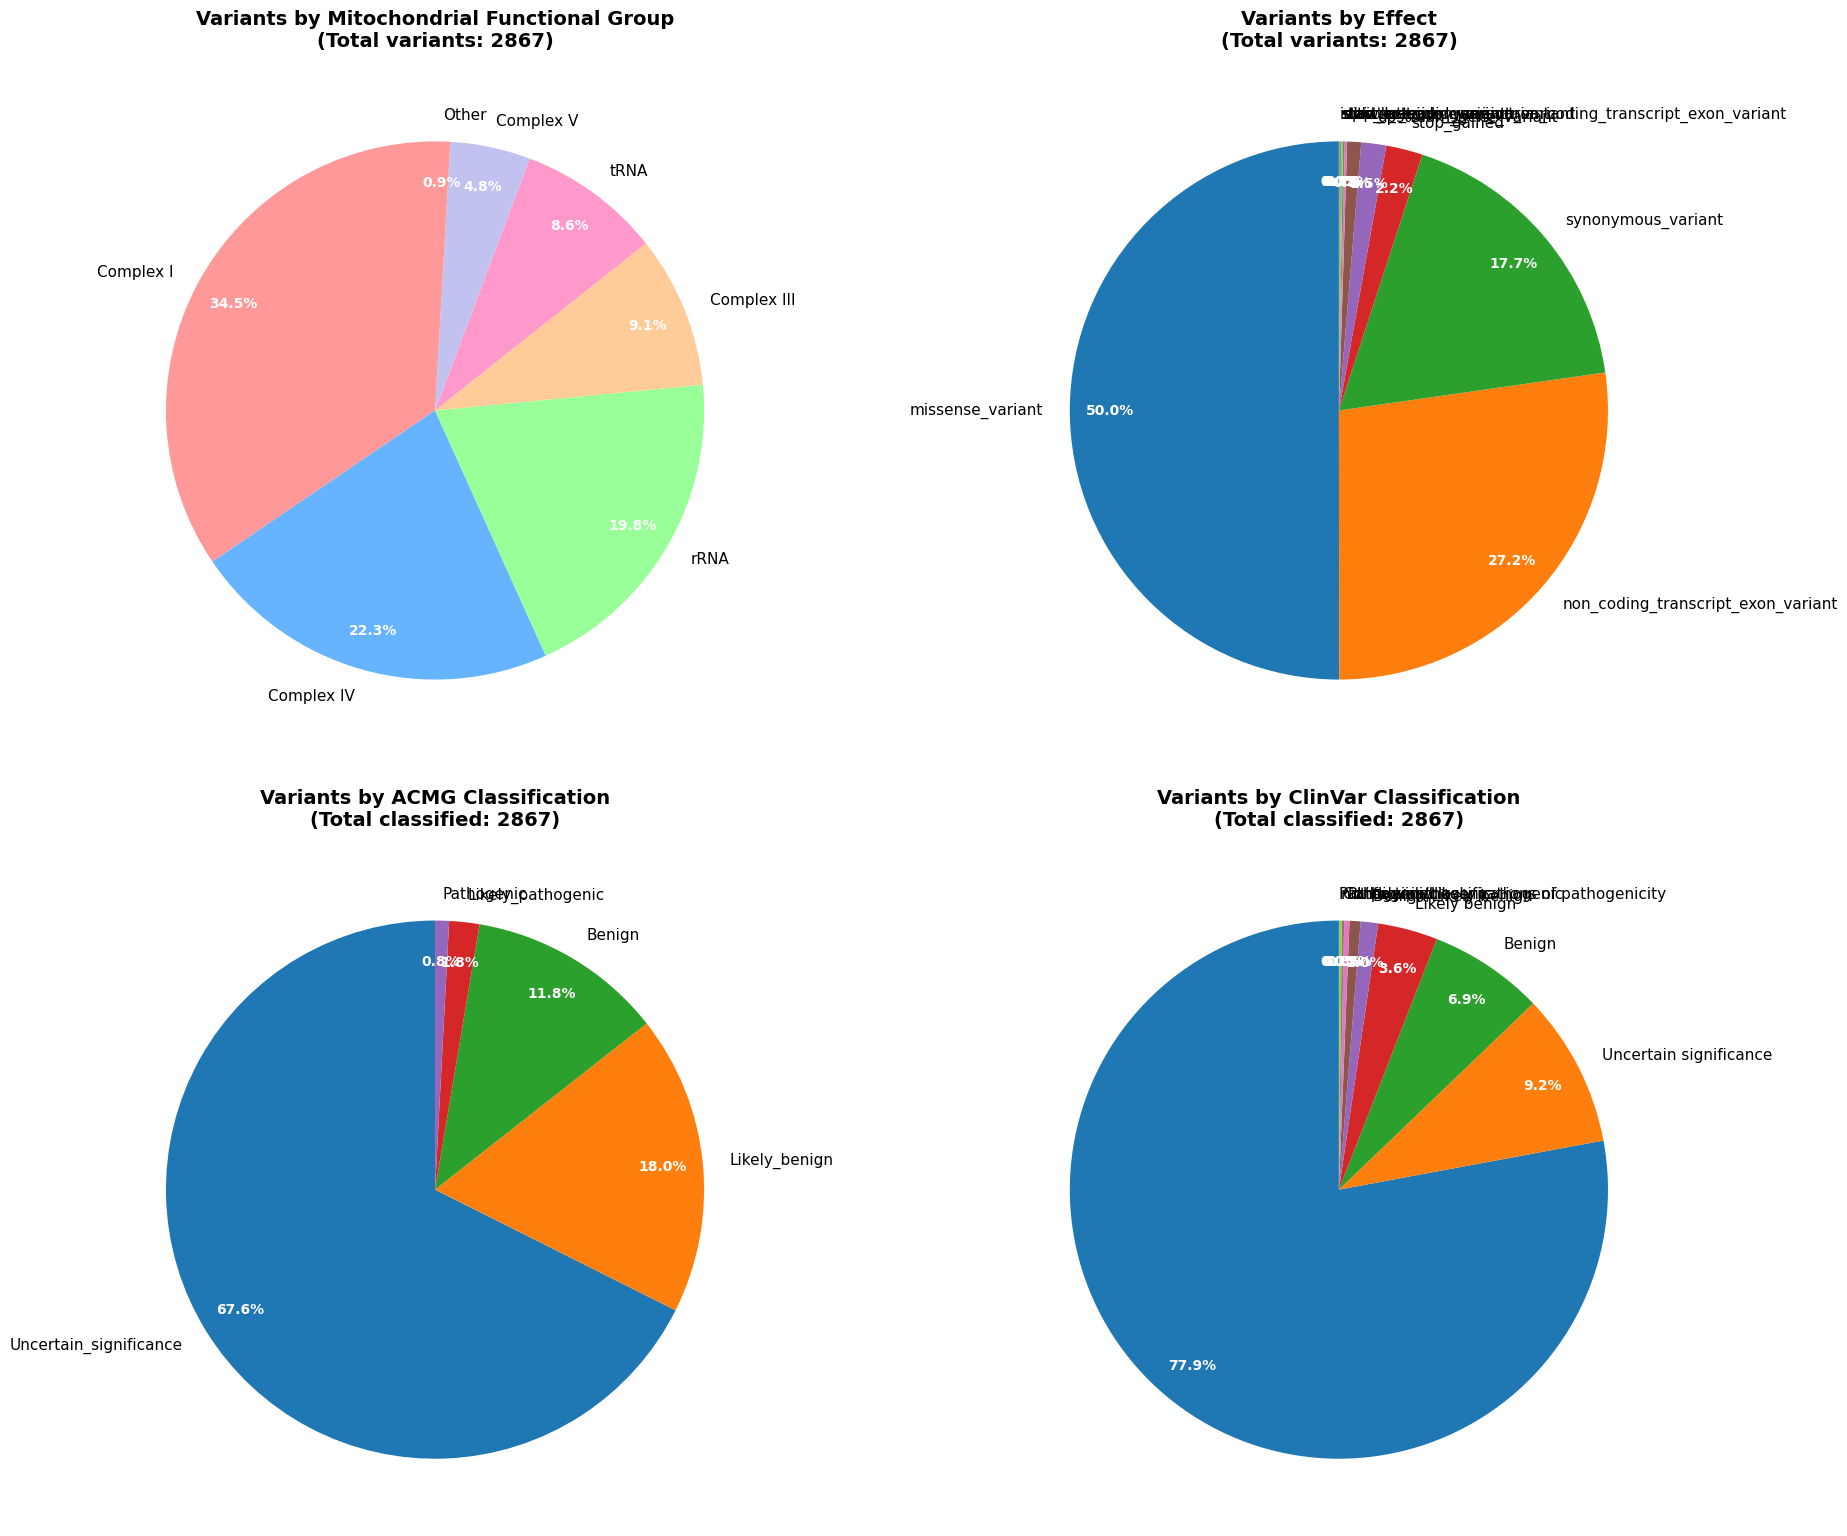

=== SUMMARY STATISTICS ===

1. Mitochondrial Functional Group Distribution:
   Total functional groups represented: 7
   Most common functional group: Complex I (989 variants)
   All functional groups:
      Complex I: 989 variants (34.5%)
      Complex IV: 638 variants (22.3%)
      rRNA: 567 variants (19.8%)
      Complex III: 262 variants (9.1%)
      tRNA: 247 variants (8.6%)
      Complex V: 138 variants (4.8%)
      Other: 26 variants (0.9%)

2. Individual Gene Symbol Distribution:
   Total genes represented: 32
   Most common gene: MT-ND5 (339 variants)
   Top 10 genes:
      1. MT-ND5 (Complex I): 339 variants (11.8%)
      2. MT-CO1 (Complex IV): 327 variants (11.4%)
      3. MT-RNR2 (rRNA): 314 variants (11.0%)
      4. MT-CYB (Complex III): 262 variants (9.1%)
      5. MT-RNR1 (rRNA): 253 variants (8.8%)
      6. MT-ND4 (Complex I): 209 variants (7.3%)
      7. MT-ND1 (Complex I): 183 variants (6.4%)
      8. MT-CO3 (Complex IV): 162 variants (5.7%)
      9. MT-CO2 (Complex 

In [ ]:
# Create a copy of the dataframe and add the functional classification
annotated_PBMC_classified = annotated_PBMC.copy()
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_symbol'].map(gene_classification)

# Handle any genes not in the classification (mark as 'Other')
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_functional_group'].fillna('Other')

# Create a 2x2 subplot layout for the pie charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))  # Increased figure size

# Function to prepare data for pie chart (handle NaN values and limit categories)
def prepare_pie_data(series, max_categories=20):
    # Count values, excluding NaN
    value_counts = series.value_counts(dropna=True)
    
    # If there are more categories than max_categories, group the smallest ones as "Other"
    if len(value_counts) > max_categories:
        top_categories = value_counts.head(max_categories - 1)
        other_count = value_counts.iloc[max_categories - 1:].sum()
        
        # Create new series with "Other" category
        pie_data = top_categories.copy()
        pie_data['Other'] = other_count
    else:
        pie_data = value_counts
    
    return pie_data

# 1. Gene Functional Group pie chart (using your classification)
gene_functional_data = prepare_pie_data(annotated_PBMC_classified['gene_functional_group'])
colors1 = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']  # Custom colors for complexes

# Option 1: Use pctdistance and labeldistance to control spacing
wedges1, texts1, autotexts1 = ax1.pie(gene_functional_data.values, labels=gene_functional_data.index, 
                                       autopct='%1.1f%%', startangle=90, 
                                       colors=colors1[:len(gene_functional_data)],
                                       pctdistance=0.85,    # Distance of percentage labels from center
                                       labeldistance=1.1)   # Distance of category labels from center

# Adjust text properties to prevent overlap
for autotext in autotexts1:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts1:
    text.set_fontsize(11)

ax1.set_title(f'Variants by Mitochondrial Functional Group\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 2. Effect pie chart with adjusted spacing
effect_data = prepare_pie_data(annotated_PBMC['effect'])
wedges2, texts2, autotexts2 = ax2.pie(effect_data.values, labels=effect_data.index, 
                                       autopct='%1.1f%%', startangle=90,
                                       pctdistance=0.85, labeldistance=1.1)

for autotext in autotexts2:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts2:
    text.set_fontsize(11)

ax2.set_title(f'Variants by Effect\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 3. ACMG Classification pie chart
acmg_data = prepare_pie_data(annotated_PBMC['acmg_classification'])
if len(acmg_data) > 0:
    wedges3, texts3, autotexts3 = ax3.pie(acmg_data.values, labels=acmg_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts3:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts3:
        text.set_fontsize(11)
    
    ax3.set_title(f'Variants by ACMG Classification\n(Total classified: {acmg_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax3.text(0.5, 0.5, 'No ACMG Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax3.set_title('ACMG Classification', fontsize=14, fontweight='bold', pad=20)

# 4. ClinVar Classification pie chart
clinvar_data = prepare_pie_data(annotated_PBMC['clinvar_classification'])
if len(clinvar_data) > 0:
    wedges4, texts4, autotexts4 = ax4.pie(clinvar_data.values, labels=clinvar_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts4:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts4:
        text.set_fontsize(11)
    
    ax4.set_title(f'Variants by ClinVar Classification\n(Total classified: {clinvar_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax4.text(0.5, 0.5, 'No ClinVar Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax4.set_title('ClinVar Classification', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout(pad=3.0)  # Add more padding between subplots
plt.show()

# Print summary statistics for each category
print("=== SUMMARY STATISTICS ===")
print(f"\n1. Mitochondrial Functional Group Distribution:")
functional_summary = annotated_PBMC_classified['gene_functional_group'].value_counts(dropna=True)
print(f"   Total functional groups represented: {len(functional_summary)}")
print(f"   Most common functional group: {functional_summary.index[0]} ({functional_summary.iloc[0]} variants)")
print(f"   All functional groups:")
for group, count in functional_summary.items():
    print(f"      {group}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n2. Individual Gene Symbol Distribution:")
gene_summary = annotated_PBMC['gene_symbol'].value_counts(dropna=True)
print(f"   Total genes represented: {len(gene_summary)}")
print(f"   Most common gene: {gene_summary.index[0]} ({gene_summary.iloc[0]} variants)")
print(f"   Top 10 genes:")
for i, (gene, count) in enumerate(gene_summary.head(10).items()):
    functional_group = gene_classification.get(gene, 'Other')
    print(f"      {i+1}. {gene} ({functional_group}): {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n3. Effect Distribution:")
effect_summary = annotated_PBMC['effect'].value_counts(dropna=True)
print(f"   Total effect types: {len(effect_summary)}")
if len(effect_summary) > 0:
    print(f"   Most common effect: {effect_summary.index[0]} ({effect_summary.iloc[0]} variants)")
    print(f"   All effects:")
    for effect, count in effect_summary.items():
        print(f"      {effect}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

acmg_summary = annotated_PBMC['acmg_classification'].value_counts(dropna=True)
print(f"\n4. ACMG Classification Distribution:")
print(f"   Total ACMG classified variants: {annotated_PBMC['acmg_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['acmg_classification'].isna().sum()}")
for classification, count in acmg_summary.items():
    print(f"      {classification}: {count} variants")

print(f"\n5. ClinVar Classification Distribution:")
clinvar_summary = annotated_PBMC['clinvar_classification'].value_counts(dropna=True)
print(f"   Total ClinVar classified variants: {annotated_PBMC['clinvar_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['clinvar_classification'].isna().sum()}")
if len(clinvar_summary) > 0:
    for classification, count in clinvar_summary.items():
        print(f"      {classification}: {count} variants")

In [ ]:
##TESTING FUNCTION 
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
from scipy.spatial.distance import cosine, pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import warnings
def analyze_clonotypes_from_variants(adata, vaf_layer_name="vaf", min_cells=1, 
                                   min_vaf=0.1, min_coverage=20, min_strand_concordance=0.3,
                                   max_variance=1, resolution=1.0, k=10):
    """
    Perform clonotype analysis using only confidently detected variants.
    
    This function integrates with the process_and_integrate_variants output
    to perform clonotype analysis based on high-confidence variant allele frequencies.
    
    Args:
        adata (anndata.AnnData): AnnData object from process_and_integrate_variants
        vaf_layer_name (str): Name of the VAF layer (default: "vaf")
        min_cells (int): Minimum number of cells with confident variant detection
        min_vaf (float): Minimum VAF threshold for confident detection (default: 10%)
        min_coverage (float): Minimum mean coverage depth for a variant
        min_strand_concordance (float): Minimum strand concordance for confident detection
        max_variance (float): Maximum VAF variance across cells (filters noisy variants)
        resolution (float): Clustering resolution
        k (int): Number of neighbors for graph construction
    
    Returns:
        anndata.AnnData: Updated AnnData object with clonotype assignments
    """
    
    # Check if we have the VAF matrix from variant calling
    vaf_matrix_key = f'{vaf_layer_name}_matrix'
    if vaf_matrix_key not in adata.obsm:
        raise ValueError(f"VAF matrix '{vaf_matrix_key}' not found in adata.obsm. "
                        "Please run process_and_integrate_variants first.")
    
    # Get VAF matrix
    vaf_matrix = adata.obsm[vaf_matrix_key]
    
    # Filter variants based on confidence criteria
    if 'variant_summary' in adata.uns:
        variant_info = adata.uns['variant_summary']
        variant_names = adata.uns['variant_names']
        
        # Apply multiple confidence filters
        confidence_filters = {
            'sufficient_coverage': variant_info['mean_coverage'] >= min_coverage,
            'strand_concordance': (variant_info['strand_concordance'] >= min_strand_concordance) | 
                                 variant_info['strand_concordance'].isna(),  # Accept NaN (single-strand variants)
            'low_variance': variant_info['variance'] <= max_variance
        }
        
        # Combine all filters
        confident_variants = pd.Series(True, index=variant_info.index)
        for filter_name, filter_mask in confidence_filters.items():
            confident_variants = confident_variants & filter_mask
            print(f"After {filter_name}: {confident_variants.sum()} variants remaining")
        
        # Get selected variants
        selected_variant_indices = confident_variants[confident_variants].index
        # The indices are actually the variant names themselves, not positions
        selected_variants = list(selected_variant_indices)
        
        # Filter VAF matrix using boolean mask
        vaf_matrix_filtered = vaf_matrix[:, confident_variants]
        
        print(f"\nFinal selection: Using {len(selected_variants)} high-confidence variants for clonotype analysis")
        print(f"Filtering criteria applied:")
        print(f"  - Confidently detected in >= {min_cells} cells")
        print(f"  - VAF >= {min_vaf} in >= {min_cells} cells") 
        print(f"  - Mean coverage >= {min_coverage}x")
        print(f"  - Strand concordance >= {min_strand_concordance} (or single-strand)")
        print(f"  - VAF variance <= {max_variance}")
        
    else:
        # Use all variants if no filtering info available (fallback)
        vaf_matrix_filtered = vaf_matrix
        selected_variants = [f"variant_{i}" for i in range(vaf_matrix.shape[1])]
        
        print(f"Warning: No variant confidence info found. Using all {vaf_matrix.shape[1]} variants for clonotype analysis")
    
    # Create temporary AnnData object with VAF data
    adata_vaf = anndata.AnnData(X=vaf_matrix_filtered)
    adata_vaf.obs_names = adata.obs_names
    adata_vaf.var_names = selected_variants
    
    # Perform clonotype analysis
    adata_vaf = find_clonotypes(
        adata_vaf, 
        layer=None,  # Use X directly
        features=None,  # Use all selected variants
        resolution=resolution,
        k=k,
        algorithm='leiden'
    )
    
    # Transfer results back to original adata
    clonotype_col = 'clonotype_leiden'
    adata.obs[clonotype_col] = adata_vaf.obs[clonotype_col]
    
    # Transfer neighbor graph
    adata.obsp['clonotype_connectivities'] = adata_vaf.obsp['clonotype_connectivities']
    adata.obsp['clonotype_distances'] = adata_vaf.obsp['clonotype_distances']
    
    # Store clonotype-specific information
    adata.uns['clonotype_analysis'] = {
        'selected_variants': selected_variants,
        'n_variants_used': len(selected_variants),
        'min_cells_threshold': min_cells,
        'min_vaf_threshold': min_vaf,
        'hierarchy': adata_vaf.uns.get('clonotype_hierarchy', None)
    }
    
    # Calculate clonotype statistics
    clonotype_stats = []
    for clonotype in adata.obs[clonotype_col].cat.categories:
        clonotype_mask = adata.obs[clonotype_col] == clonotype
        n_cells = clonotype_mask.sum()
        
        # Get variants characteristic of this clonotype
        clonotype_vaf = vaf_matrix_filtered[clonotype_mask, :]
        mean_vaf = np.mean(clonotype_vaf, axis=0)
        
        # Find variants with high mean VAF in this clonotype
        high_vaf_variants = np.where(mean_vaf > min_vaf)[0]
        characteristic_variants = [selected_variants[i] for i in high_vaf_variants]
        
        clonotype_stats.append({
            'clonotype': clonotype,
            'n_cells': n_cells,
            'n_characteristic_variants': len(characteristic_variants),
            'characteristic_variants': characteristic_variants,
            'mean_vaf_all_variants': np.mean(mean_vaf)
        })
    
    adata.uns['clonotype_stats'] = pd.DataFrame(clonotype_stats)
    
    print(f"Identified {len(adata.obs[clonotype_col].cat.categories)} clonotypes")
    print(f"Clonotype sizes: {adata.obs[clonotype_col].value_counts().to_dict()}")
    
    return adata

In [ ]:
## Trying to evaluate clonotyping 
import Py_mTCall_tools.clonotype_analysis
#importlib.reload(Py_mTCall_tools.clonotype_analysis)

# Now import the confidence summary function directly

from Py_mTCall_tools.clonotype_analysis import analyze_clonotypes_from_variants
from Py_mTCall_tools import (
    analyze_clonotypes_from_variants,
    plot_clonotype_vaf_heatmap,
    cluster_clonotypes,
    find_clonotypes
)

In [ ]:
# Boolean mask: True for variants with at least one retained (non-zero) cell
high_quality_mask = (high_quality_vaf_matrix > 0).any(axis=0)

# Get corresponding variant names
high_quality_variant_names = np.array(variant_names)[high_quality_mask]
print(high_quality_variant_names)
print(len(high_quality_variant_names))

## Flip variants to match format 
converted = [f"MT-{alt}-{pos}-{ref}" for ref, pos, alt in (v.split('-') for v in high_quality_variant_names)]
print(converted)

required_columns = ["chr", "pos", "ref", "alt"]

genebe_df = pd.DataFrame(
    [v.split('-') for v in converted],
    columns=["chr","ref", "pos", "alt"]
)
genebe_df = genebe_df[required_columns]

print(genebe_df.head())

['A-10172-G' 'A-11163-G' 'A-11415-C' ... 'G-8860-A' 'G-982-A' 'T-3843-A']
2867
['MT-G-10172-A', 'MT-G-11163-A', 'MT-C-11415-A', 'MT-G-11719-A', 'MT-T-11838-A', 'MT-C-11858-A', 'MT-C-1204-A', 'MT-C-12412-A', 'MT-G-1252-A', 'MT-G-12583-A', 'MT-C-12861-A', 'MT-C-13043-A', 'MT-C-13329-A', 'MT-G-13558-A', 'MT-G-13730-A', 'MT-G-1476-A', 'MT-G-15093-A', 'MT-G-15301-A', 'MT-G-15708-A', 'MT-G-1719-A', 'MT-G-1949-A', 'MT-G-2174-A', 'MT-G-2553-A', 'MT-g-3255-A', 'MT-G-3688-A', 'MT-G-3850-A', 'MT-G-3901-A', 'MT-c-4393-A', 'MT-G-4482-A', 'MT-G-4830-A', 'MT-G-4849-A', 'MT-G-5245-A', 'MT-G-529-A', 'MT-G-5590-A', 'MT-T-5801-A', 'MT-C-5846-A', 'MT-G-6069-A', 'MT-G-6999-A', 'MT-C-7235-A', 'MT-G-7239-A', 'MT-C-7629-A', 'MT-G-769-A', 'MT-G-8007-A', 'MT-G-8189-A', 'MT-T-8597-A', 'MT-G-874-A', 'MT-G-9267-A', 'MT-G-9554-A', 'MT-G-9906-A', 'MT-G-10172-C', 'MT-T-11147-C', 'MT-T-11759-C', 'MT-T-11784-C', 'MT-T-12438-C', 'MT-T-12448-C', 'MT-T-1259-C', 'MT-T-12755-C', 'MT-T-12851-C', 'MT-T-13698-C', 'MT-T-13781-C

In [ ]:
##Filter the mgatk adata object for high quality variants prior to clonotyping
# Filter all the variant matrices
# Create a filtered copy of mgatk with only high-quality variants
mgatk_filtered = mgatk.copy()
mgatk_filtered.obsm['variant_vaf'] = mgatk.obsm['variant_vaf'][:, high_quality_mask]
mgatk_filtered.obsm['variant_vaf_high_quality'] = mgatk.obsm['variant_vaf_high_quality'][:, high_quality_mask]
mgatk_filtered.obsm['variant_coverage'] = mgatk.obsm['variant_coverage'][:, high_quality_mask]
mgatk_filtered.obsm['variant_confident'] = mgatk.obsm['variant_confident'][:, high_quality_mask]

# Filter the variant info
mgatk_filtered.uns['variant_names'] = list(high_quality_variant_names)
mgatk_filtered.uns['variant_summary'] = mgatk.uns['variant_summary'].iloc[high_quality_mask].reset_index(drop=True)

print(f"Filtered mgatk object now contains {len(mgatk_filtered.uns['variant_names'])} variants")


Filtered mgatk object now contains 2867 variants


In [ ]:
# Use the high-quality filtered VAF matrix for clonotype analysis
mgatk_filtered.obsm['variant_vaf_high_quality_matrix'] = mgatk_filtered.obsm['variant_vaf_high_quality']
mgatk_with_clonotypes = analyze_clonotypes_from_variants(
    mgatk_filtered,
    vaf_layer_name="variant_vaf_high_quality",  # Use your high-quality filtered data              # High threshold since you WANT variance ≥0.01
    resolution=0.2,
    min_vaf=0.1,
    min_coverage=10,   
                              # Might need to adjust resolution
    k=10                           # Number of neighbors for graph construction
)


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning:

Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.

/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Py-mTCall/Py_mTCall_tools/clonotype_analysis.py:198: FutureWarning:

In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.



Identified 28 clonotypes
Clonotype sizes: {'clonotype_23': 3196, 'clonotype_15': 1450, 'clonotype_27': 860, 'clonotype_21': 250, 'clonotype_19': 215, 'clonotype_22': 212, 'clonotype_14': 206, 'clonotype_24': 205, 'clonotype_18': 161, 'clonotype_17': 125, 'clonotype_20': 117, 'clonotype_16': 115, 'clonotype_9': 96, 'clonotype_11': 69, 'clonotype_2': 65, 'clonotype_3': 63, 'clonotype_1': 50, 'clonotype_4': 45, 'clonotype_12': 23, 'clonotype_10': 18, 'clonotype_5': 17, 'clonotype_7': 13, 'clonotype_26': 13, 'clonotype_25': 10, 'clonotype_0': 10, 'clonotype_6': 8, 'clonotype_8': 8, 'clonotype_13': 6}


PTPRC+ cells: 4841
PTPRC- cells: 2785

ANALYZING PTPRC+ CELLS (T cells)


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning:

Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.



Identified 47 clonotypes
Clonotype sizes: {'clonotype_35': 2096, 'clonotype_20': 716, 'clonotype_46': 285, 'clonotype_31': 156, 'clonotype_19': 143, 'clonotype_21': 140, 'clonotype_15': 109, 'clonotype_33': 103, 'clonotype_30': 92, 'clonotype_32': 83, 'clonotype_29': 81, 'clonotype_22': 78, 'clonotype_27': 72, 'clonotype_10': 71, 'clonotype_34': 69, 'clonotype_8': 68, 'clonotype_26': 67, 'clonotype_25': 66, 'clonotype_28': 55, 'clonotype_37': 33, 'clonotype_24': 27, 'clonotype_11': 24, 'clonotype_23': 22, 'clonotype_0': 15, 'clonotype_16': 15, 'clonotype_5': 13, 'clonotype_9': 10, 'clonotype_45': 10, 'clonotype_14': 10, 'clonotype_3': 9, 'clonotype_36': 9, 'clonotype_44': 9, 'clonotype_2': 9, 'clonotype_43': 8, 'clonotype_41': 7, 'clonotype_40': 6, 'clonotype_13': 6, 'clonotype_42': 6, 'clonotype_6': 6, 'clonotype_18': 6, 'clonotype_7': 5, 'clonotype_17': 5, 'clonotype_4': 5, 'clonotype_39': 5, 'clonotype_38': 4, 'clonotype_1': 4, 'clonotype_12': 3}

Creating PTPRC+ clonotype VAF heatm

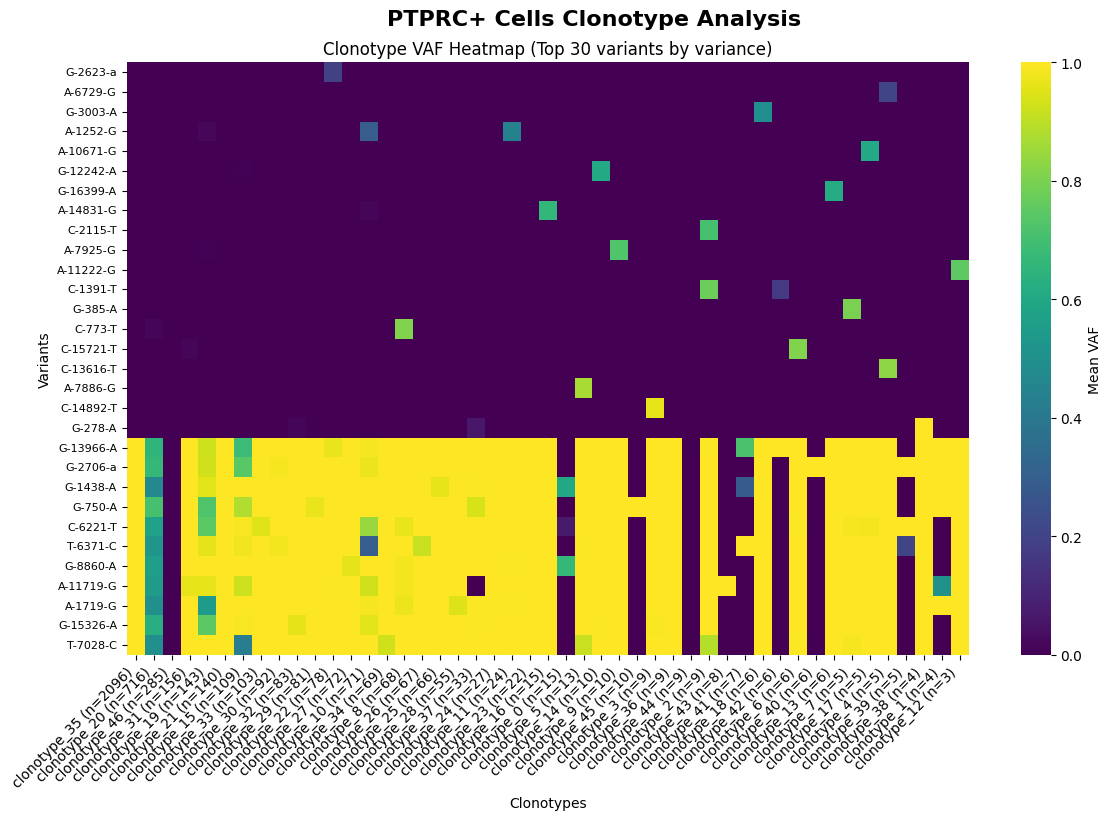


=== PTPRC+ CLONOTYPE STATISTICS ===
Number of clonotypes: 47

Clonotype sizes:
clonotype_leiden
clonotype_35    2096
clonotype_20     716
clonotype_46     285
clonotype_31     156
clonotype_19     143
clonotype_21     140
clonotype_15     109
clonotype_33     103
clonotype_30      92
clonotype_32      83
clonotype_29      81
clonotype_22      78
clonotype_27      72
clonotype_10      71
clonotype_34      69
clonotype_8       68
clonotype_26      67
clonotype_25      66
clonotype_28      55
clonotype_37      33
clonotype_24      27
clonotype_11      24
clonotype_23      22
clonotype_16      15
clonotype_0       15
clonotype_5       13
clonotype_14      10
clonotype_9       10
clonotype_45      10
clonotype_3        9
clonotype_36       9
clonotype_44       9
clonotype_2        9
clonotype_43       8
clonotype_41       7
clonotype_18       6
clonotype_42       6
clonotype_6        6
clonotype_40       6
clonotype_13       6
clonotype_7        5
clonotype_17       5
clonotype_4        5


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning:

Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



Identified 13 clonotypes
Clonotype sizes: {'clonotype_11': 978, 'clonotype_4': 576, 'clonotype_7': 574, 'clonotype_12': 285, 'clonotype_10': 108, 'clonotype_6': 82, 'clonotype_5': 67, 'clonotype_8': 46, 'clonotype_2': 24, 'clonotype_9': 23, 'clonotype_0': 9, 'clonotype_1': 7, 'clonotype_3': 6}

Creating PTPRC- clonotype VAF heatmap...


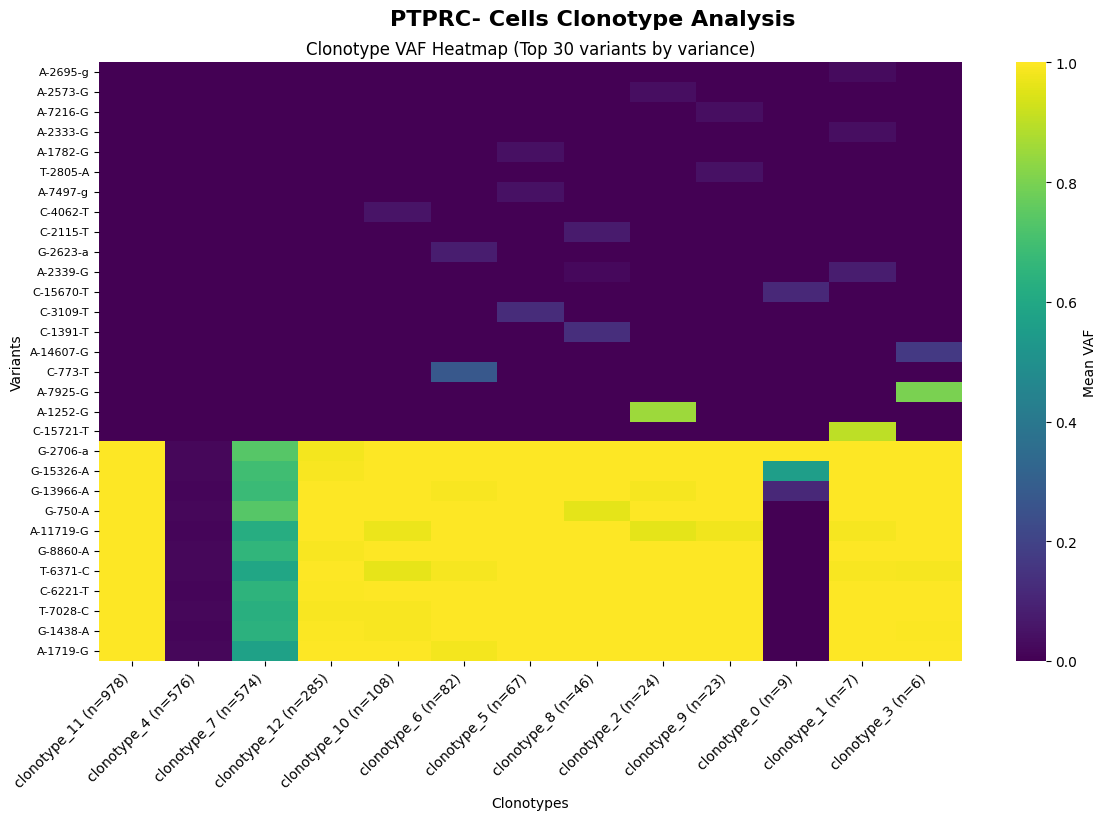


=== PTPRC- CLONOTYPE STATISTICS ===
Number of clonotypes: 13

Clonotype sizes:
clonotype_leiden
clonotype_11    978
clonotype_4     576
clonotype_7     574
clonotype_12    285
clonotype_10    108
clonotype_6      82
clonotype_5      67
clonotype_8      46
clonotype_2      24
clonotype_9      23
clonotype_0       9
clonotype_1       7
clonotype_3       6
Name: count, dtype: int64

=== COMPARISON SUMMARY ===
PTPRC+ cells:
  Total cells analyzed: 4841
  Number of clonotypes: 47
  Largest clonotype size: 2096

PTPRC- cells:
  Total cells analyzed: 2785
  Number of clonotypes: 13
  Largest clonotype size: 978


In [ ]:
# Clonotype analysis for PTPRC+ and PTPRC- cells separately
import numpy as np
import pandas as pd

# Get PTPRC expression masks
if 'PTPRC' in gene_matrix.var.index:
    ptprc_expression = gene_matrix[:, 'PTPRC'].X.toarray().flatten()
    ptprc_positive_mask = ptprc_expression > 0
    ptprc_negative_mask = ptprc_expression == 0
    
    print(f"PTPRC+ cells: {ptprc_positive_mask.sum()}")
    print(f"PTPRC- cells: {ptprc_negative_mask.sum()}")
    
    # ========== PTPRC+ CELLS CLONOTYPE ANALYSIS ==========
    print("\n" + "="*80)
    print("ANALYZING PTPRC+ CELLS (T cells)")
    print("="*80)
    
    # Filter mgatk_filtered for PTPRC+ cells only
    mgatk_ptprc_pos = mgatk_filtered[ptprc_positive_mask].copy()
    
    # Run clonotype analysis on PTPRC+ cells
    mgatk_ptprc_pos.obsm['variant_vaf_high_quality_matrix'] = mgatk_ptprc_pos.obsm['variant_vaf_high_quality']
    mgatk_ptprc_pos_clonotypes = analyze_clonotypes_from_variants(
        mgatk_ptprc_pos,
        vaf_layer_name="variant_vaf_high_quality",
        resolution=0.5,
        min_vaf=0.1,
        min_coverage=10,
        k=5
    )
    
    # Create heatmap for PTPRC+ clonotypes
    print("\nCreating PTPRC+ clonotype VAF heatmap...")
    fig_pos = plot_clonotype_vaf_heatmap(
        mgatk_ptprc_pos_clonotypes,
        vaf_layer_name="variant_vaf_high_quality",
        clonotype_col="clonotype_leiden",
        top_variants=30,
        figsize=(12, 8)
    )
    
    # Adjust colormap
    for ax in fig_pos.get_axes():
        images = ax.get_images()
        if images:
            images[0].set_cmap('plasma')
            from matplotlib.colors import PowerNorm
            images[0].set_norm(PowerNorm(gamma=0.5))
            break
    
    fig_pos.suptitle('PTPRC+ Cells Clonotype Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    # Print PTPRC+ clonotype stats
    print("\n=== PTPRC+ CLONOTYPE STATISTICS ===")
    print(f"Number of clonotypes: {len(mgatk_ptprc_pos_clonotypes.obs['clonotype_leiden'].cat.categories)}")
    print("\nClonotype sizes:")
    print(mgatk_ptprc_pos_clonotypes.obs['clonotype_leiden'].value_counts().sort_index())
    
    # ========== PTPRC- CELLS CLONOTYPE ANALYSIS ==========
    print("\n" + "="*80)
    print("ANALYZING PTPRC- CELLS (Non-T cells)")
    print("="*80)
    
    # Filter mgatk_filtered for PTPRC- cells only
    mgatk_ptprc_neg = mgatk_filtered[ptprc_negative_mask].copy()
    
    # Run clonotype analysis on PTPRC- cells
    mgatk_ptprc_neg.obsm['variant_vaf_high_quality_matrix'] = mgatk_ptprc_neg.obsm['variant_vaf_high_quality']
    mgatk_ptprc_neg_clonotypes = analyze_clonotypes_from_variants(
        mgatk_ptprc_neg,
        vaf_layer_name="variant_vaf_high_quality",
        resolution=0.2,
        min_vaf=0.1,
        min_coverage=10,
        k=5
    )
    
    # Create heatmap for PTPRC- clonotypes
    print("\nCreating PTPRC- clonotype VAF heatmap...")
    fig_neg = plot_clonotype_vaf_heatmap(
        mgatk_ptprc_neg_clonotypes,
        vaf_layer_name="variant_vaf_high_quality",
        clonotype_col="clonotype_leiden",
        top_variants=30,
        figsize=(12, 8)
    )
    
    # Adjust colormap
    for ax in fig_neg.get_axes():
        images = ax.get_images()
        if images:
            images[0].set_cmap('plasma')
            from matplotlib.colors import PowerNorm
            images[0].set_norm(PowerNorm(gamma=0.5))
            break
    
    fig_neg.suptitle('PTPRC- Cells Clonotype Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    # Print PTPRC- clonotype stats
    print("\n=== PTPRC- CLONOTYPE STATISTICS ===")
    print(f"Number of clonotypes: {len(mgatk_ptprc_neg_clonotypes.obs['clonotype_leiden'].cat.categories)}")
    print("\nClonotype sizes:")
    print(mgatk_ptprc_neg_clonotypes.obs['clonotype_leiden'].value_counts().sort_index())
    
    # ========== COMPARISON SUMMARY ==========
    print("\n" + "="*80)
    print("=== COMPARISON SUMMARY ===")
    print("="*80)
    print(f"PTPRC+ cells:")
    print(f"  Total cells analyzed: {len(mgatk_ptprc_pos_clonotypes)}")
    print(f"  Number of clonotypes: {len(mgatk_ptprc_pos_clonotypes.obs['clonotype_leiden'].cat.categories)}")
    print(f"  Largest clonotype size: {mgatk_ptprc_pos_clonotypes.obs['clonotype_leiden'].value_counts().max()}")
    
    print(f"\nPTPRC- cells:")
    print(f"  Total cells analyzed: {len(mgatk_ptprc_neg_clonotypes)}")
    print(f"  Number of clonotypes: {len(mgatk_ptprc_neg_clonotypes.obs['clonotype_leiden'].cat.categories)}")
    print(f"  Largest clonotype size: {mgatk_ptprc_neg_clonotypes.obs['clonotype_leiden'].value_counts().max()}")

else:
    print("PTPRC not found in gene matrix")